# 01 - Exploration des Données (EDA Complet)

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuration visualisations
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 6)

# Chemins
DATA_RAW = Path('../data/raw')

## 2. Chargement des Données BRUTES

In [3]:
print("=" * 80)
print("CHARGEMENT DES DONNÉES BRUTES")
print("=" * 80)

# Charger tous les fichiers
interactions_train = pd.read_csv(DATA_RAW / 'interactions_train.csv')
interactions_val = pd.read_csv(DATA_RAW / 'interactions_validation.csv')
interactions_test = pd.read_csv(DATA_RAW / 'interactions_test.csv')
recipes = pd.read_csv(DATA_RAW / 'RAW_recipes.csv')
users = pd.read_csv(DATA_RAW / 'PP_users.csv')

print(f"\n FICHIERS CHARGÉS:")
print(f"   •interactions_train:     {interactions_train.shape}")
print(f"   • recipes (RAW):          {recipes.shape}")
print(f"   • users (PP):             {users.shape}")

print(f"\n COLONNES DES FICHIERS:")
print(f"\n   interactions_train: {interactions_train.columns.tolist()}")
print(f"\n   recipes:      {recipes.columns.tolist()}")
print(f"\n   users:        {users.columns.tolist()}")

CHARGEMENT DES DONNÉES BRUTES

 FICHIERS CHARGÉS:
   •interactions_train:     (698901, 6)
   • recipes (RAW):          (231637, 12)
   • users (PP):             (25076, 6)

 COLONNES DES FICHIERS:

   interactions_train: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']

   recipes:      ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']

   users:        ['u', 'techniques', 'items', 'n_items', 'ratings', 'n_ratings']


## 3. EDA - Interactions (train)

In [4]:
print("\n APERÇU DES DONNÉES:")
print(interactions_train.head())

print(f"\n STATISTIQUES:")
print(interactions_train.describe())

print(f"\n VALEURS MANQUANTES:")
print(interactions_train.isnull().sum())

print(f"\n VALEURS UNIQUES:")
print(f"   • Nombre d'utilisateurs uniques: {interactions_train['user_id'].nunique():,}")
print(f"   • Nombre de recettes uniques:    {interactions_train['recipe_id'].nunique():,}")
print(f"   • Nombre total d'interactions:   {len(interactions_train):,}")

print(f"\n DISTRIBUTION DES RATINGS:")
print(interactions_train['rating'].value_counts().sort_index())


 APERÇU DES DONNÉES:
   user_id  recipe_id        date  rating      u       i
0     2046       4684  2000-02-25     5.0  22095   44367
1     2046        517  2000-02-25     5.0  22095   87844
2     1773       7435  2000-03-13     5.0  24732  138181
3     1773        278  2000-03-13     4.0  24732   93054
4     2046       3431  2000-04-07     5.0  22095  101723

 STATISTIQUES:
            user_id      recipe_id         rating              u  \
count  6.989010e+05  698901.000000  698901.000000  698901.000000   
mean   1.247694e+07  156173.409849       4.574090    4249.330271   
std    1.525031e+08  126594.880211       0.959022    5522.602821   
min    1.533000e+03      38.000000       0.000000       0.000000   
25%    1.059880e+05   53169.000000       4.000000     455.000000   
50%    2.301020e+05  116484.000000       5.000000    1737.000000   
75%    4.801950e+05  234516.000000       5.000000    5919.000000   
max    2.002313e+09  537458.000000       5.000000   25075.000000   

       

### Comparaison Train / Validation / Test

In [5]:
print("=" * 80)
print("COMPARAISON DES ENSEMBLES TRAIN / VALIDATION / TEST")
print("=" * 80)

# Statistiques de base
datasets = {
    'Train': interactions_train,
    'Validation': interactions_val,
    'Test': interactions_test
}

print(f"\n📊 TAILLES DES ENSEMBLES:")
for name, df in datasets.items():
    print(f"   {name:<12}: {len(df):>8,} interactions")

total = sum(len(df) for df in datasets.values())
print(f"\n   Total:        {total:>8,}")
print(f"\n📈 PROPORTIONS:")
for name, df in datasets.items():
    pct = 100 * len(df) / total
    print(f"   {name:<12}: {pct:>6.2f}%")

print(f"\n👥 UTILISATEURS UNIQUES:")
for name, df in datasets.items():
    print(f"   {name:<12}: {df['user_id'].nunique():>8,} users")

print(f"\n🍳 RECETTES UNIQUES:")
for name, df in datasets.items():
    print(f"   {name:<12}: {df['recipe_id'].nunique():>8,} recettes")

print(f"\n⭐ STATISTIQUES RATINGS:")
stats_df = pd.DataFrame({
    name: df['rating'].describe() 
    for name, df in datasets.items()
})
print(stats_df)

COMPARAISON DES ENSEMBLES TRAIN / VALIDATION / TEST

📊 TAILLES DES ENSEMBLES:
   Train       :  698,901 interactions
   Validation  :    7,023 interactions
   Test        :   12,455 interactions

   Total:         718,379

📈 PROPORTIONS:
   Train       :  97.29%
   Validation  :   0.98%
   Test        :   1.73%

👥 UTILISATEURS UNIQUES:
   Train       :   25,076 users
   Validation  :    7,023 users
   Test        :   12,455 users

🍳 RECETTES UNIQUES:


   Train       :  160,901 recettes
   Validation  :    6,621 recettes
   Test        :   11,695 recettes

⭐ STATISTIQUES RATINGS:
               Train   Validation          Test
count  698901.000000  7023.000000  12455.000000
mean        4.574090     4.232806      4.213087
std         0.959022     1.302910      1.338503
min         0.000000     0.000000      0.000000
25%         4.000000     4.000000      4.000000
50%         5.000000     5.000000      5.000000
75%         5.000000     5.000000      5.000000
max         5.000000     5.000000      5.000000


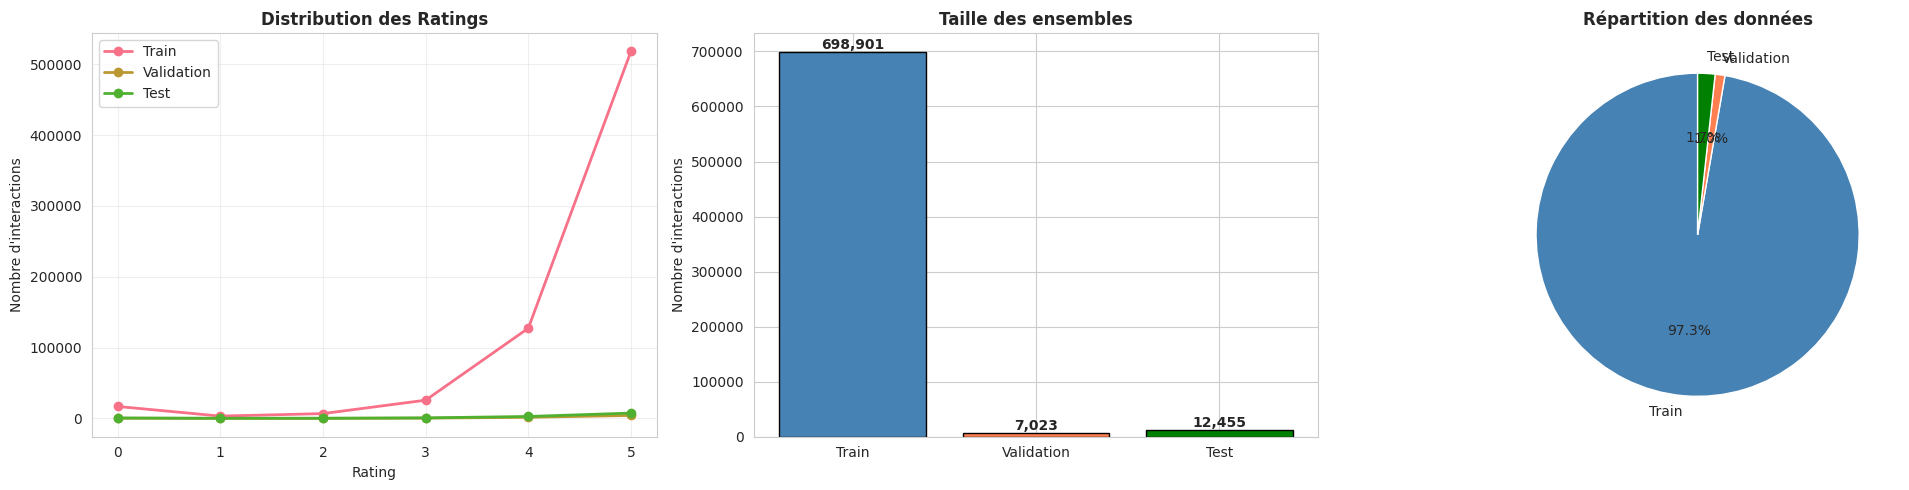


🔍 CHEVAUCHEMENT DES DONNÉES:

   Users:
      Train ∩ Val:   7,023
      Train ∩ Test: 12,455
      Val ∩ Test:    5,839

   Recettes:
      Train ∩ Val:       0
      Train ∩ Test:      0
      Val ∩ Test:      952


In [6]:
# Visualisations comparaison Train/Val/Test
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Distribution des ratings
for name, df in datasets.items():
    rating_dist = df['rating'].value_counts().sort_index()
    axes[0].plot(rating_dist.index, rating_dist.values, marker='o', label=name, linewidth=2)
axes[0].set_title('Distribution des Ratings', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Nombre d\'interactions')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Comparaison tailles
sizes = [len(df) for df in datasets.values()]
axes[1].bar(datasets.keys(), sizes, color=['steelblue', 'coral', 'green'], edgecolor='black')
axes[1].set_title('Taille des ensembles', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre d\'interactions')
for i, v in enumerate(sizes):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Proportions en pie chart
axes[2].pie(sizes, labels=datasets.keys(), autopct='%1.1f%%', 
            colors=['steelblue', 'coral', 'green'], startangle=90)
axes[2].set_title('Répartition des données', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Vérification chevauchement users/recipes
print(f"\n🔍 CHEVAUCHEMENT DES DONNÉES:")
train_users = set(interactions_train['user_id'])
val_users = set(interactions_val['user_id'])
test_users = set(interactions_test['user_id'])

print(f"\n   Users:")
print(f"      Train ∩ Val:  {len(train_users & val_users):>6,}")
print(f"      Train ∩ Test: {len(train_users & test_users):>6,}")
print(f"      Val ∩ Test:   {len(val_users & test_users):>6,}")

train_recipes = set(interactions_train['recipe_id'])
val_recipes = set(interactions_val['recipe_id'])
test_recipes = set(interactions_test['recipe_id'])

print(f"\n   Recettes:")
print(f"      Train ∩ Val:  {len(train_recipes & val_recipes):>6,}")
print(f"      Train ∩ Test: {len(train_recipes & test_recipes):>6,}")
print(f"      Val ∩ Test:   {len(val_recipes & test_recipes):>6,}")

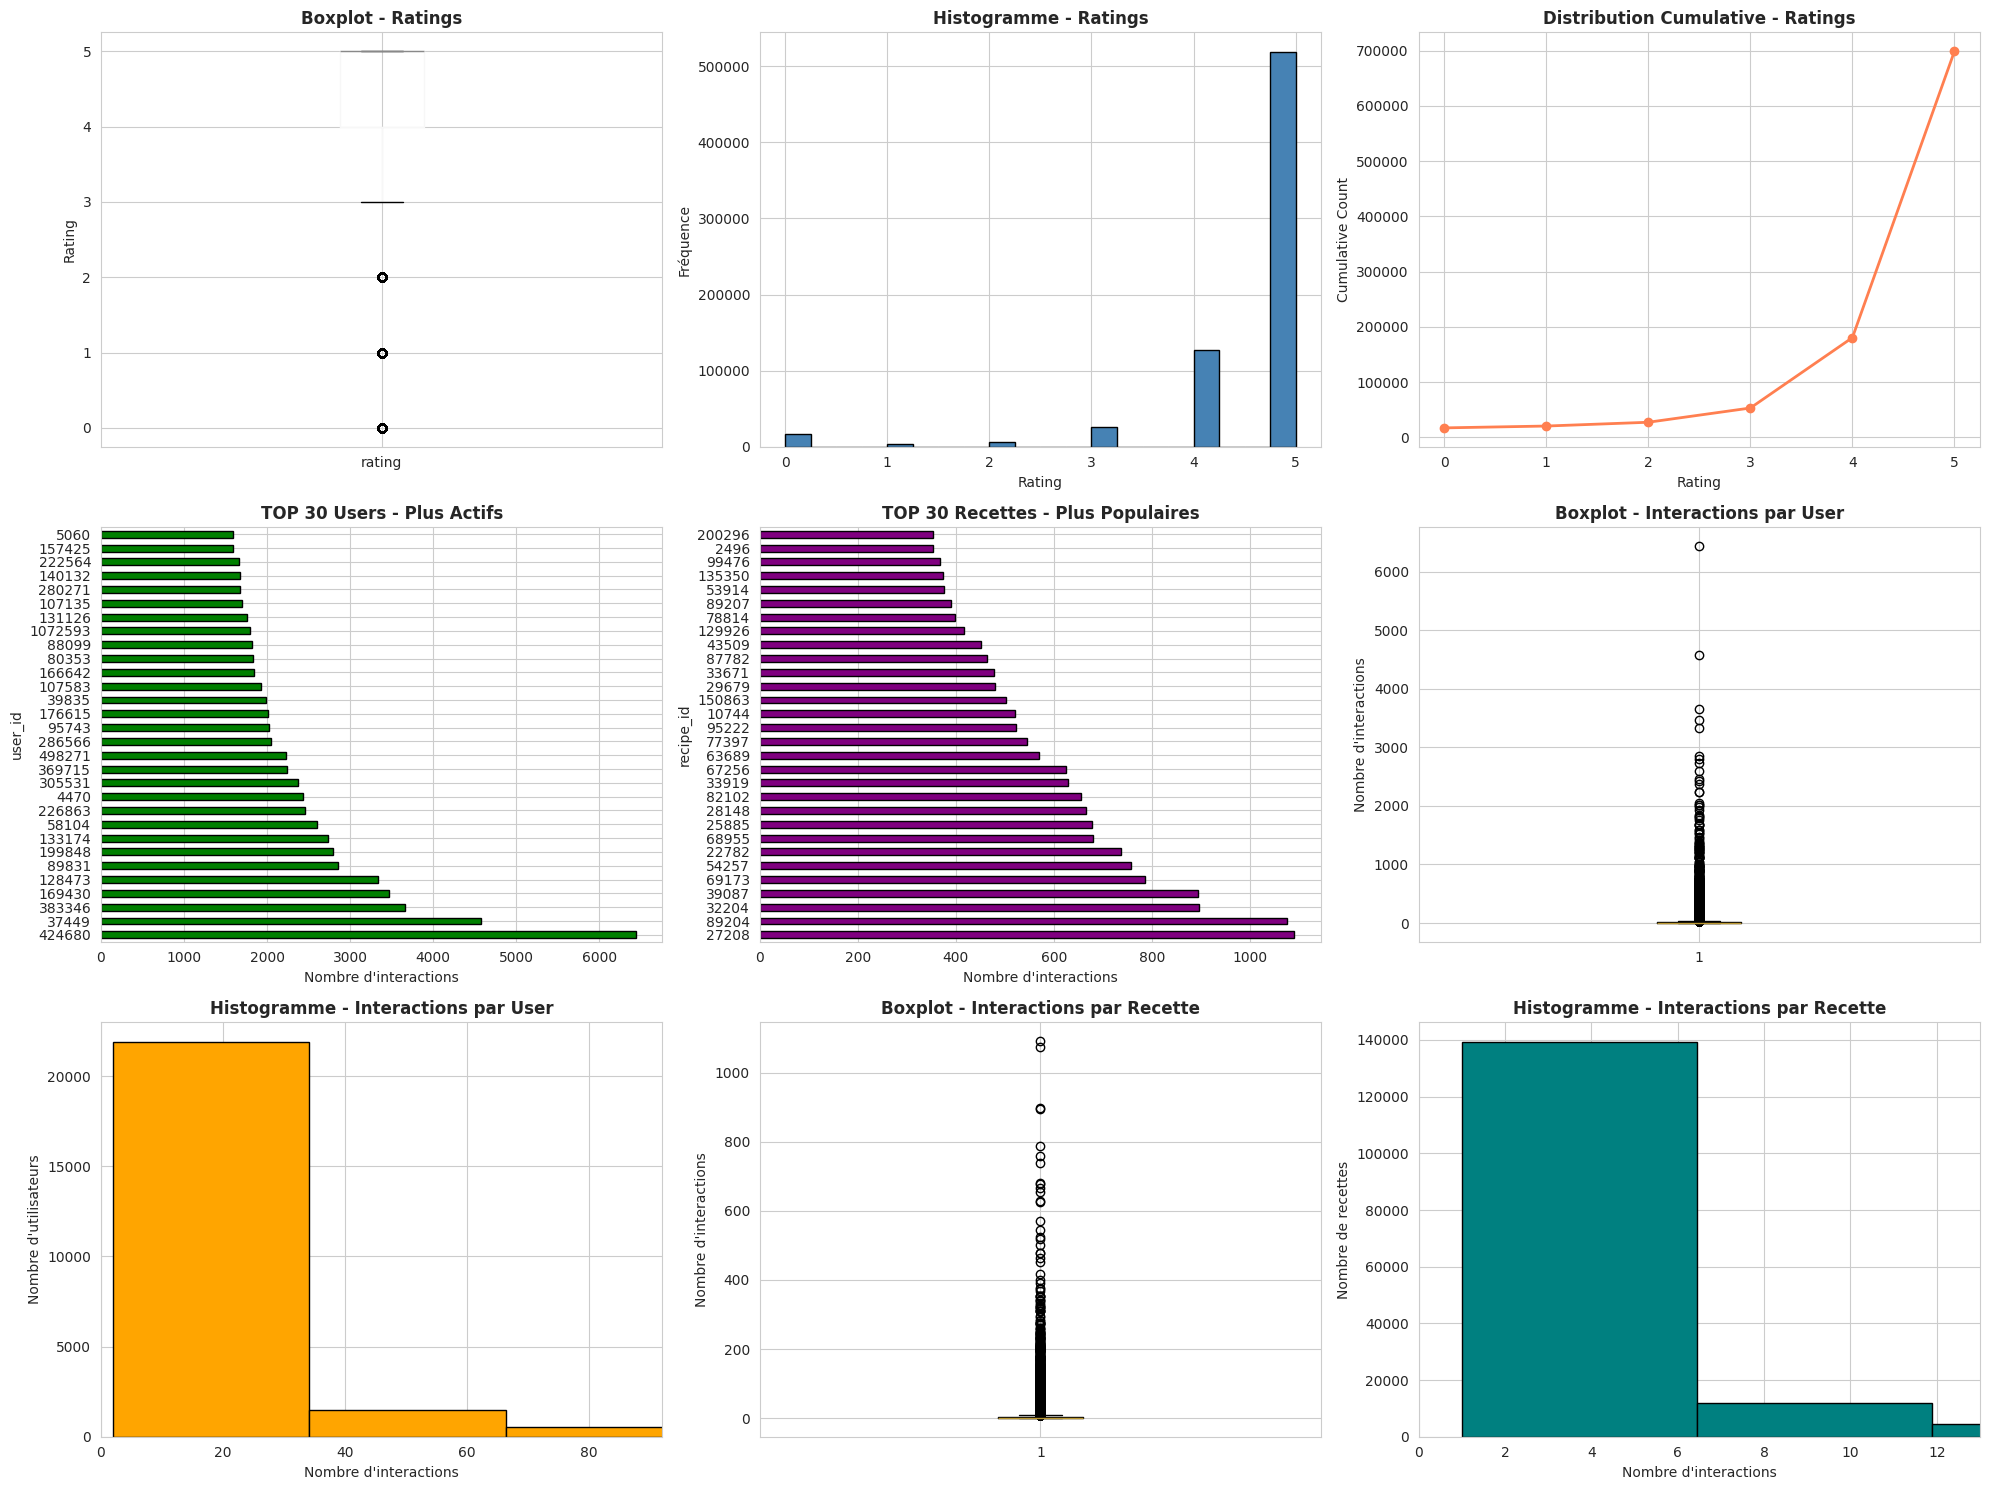


 INSIGHTS INTERACTIONS:
   • Rating moyen: 4.57
   • Rating médian: 5
   • % de ratings 5 étoiles: 74.2%
   • Interactions par user (moyenne): 27.9
   • Interactions par user (médiane): 6
   • Interactions par recette (moyenne): 4.3
   • Interactions par recette (médiane): 2


In [7]:
# Visualisations APPROFONDIES - Interactions
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# 1. Boxplot ratings
interactions_train.boxplot(column='rating', ax=axes[0, 0])
axes[0, 0].set_title('Boxplot - Ratings', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Rating')

# 2. Histogramme ratings
interactions_train['rating'].hist(bins=20, ax=axes[0, 1], color='steelblue', edgecolor='black')
axes[0, 1].set_title('Histogramme - Ratings', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Rating')
axes[0, 1].set_ylabel('Fréquence')

# 3. Distribution cumulative ratings
interactions_train['rating'].value_counts().sort_index().cumsum().plot(kind='line', ax=axes[0, 2], marker='o', linewidth=2, markersize=6, color='coral')
axes[0, 2].set_title('Distribution Cumulative - Ratings', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Rating')
axes[0, 2].set_ylabel('Cumulative Count')

# 4. Top 30 users les plus actifs
top_users = interactions_train['user_id'].value_counts().head(30)
top_users.plot(kind='barh', ax=axes[1, 0], color='green', edgecolor='black')
axes[1, 0].set_title('TOP 30 Users - Plus Actifs', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Nombre d\'interactions')

# 5. Top 30 recettes les plus populaires
top_recipes = interactions_train['recipe_id'].value_counts().head(30)
top_recipes.plot(kind='barh', ax=axes[1, 1], color='purple', edgecolor='black')
axes[1, 1].set_title('TOP 30 Recettes - Plus Populaires', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Nombre d\'interactions')

# 6. Boxplot - Interactions par user
user_interaction_counts = interactions_train.groupby('user_id').size()
axes[1, 2].boxplot(user_interaction_counts, vert=True)
axes[1, 2].set_title('Boxplot - Interactions par User', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Nombre d\'interactions')

# 7. Histogramme - Interactions par user
user_interaction_counts.hist(bins=200, ax=axes[2, 0], color='orange', edgecolor='black')
axes[2, 0].set_title('Histogramme - Interactions par User', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Nombre d\'interactions')
axes[2, 0].set_ylabel('Nombre d\'utilisateurs')
axes[2, 0].set_xlim([0, user_interaction_counts.quantile(0.95)])

# 8. Boxplot - Interactions par recette
recipe_interaction_counts = interactions_train.groupby('recipe_id').size()
axes[2, 1].boxplot(recipe_interaction_counts, vert=True)
axes[2, 1].set_title('Boxplot - Interactions par Recette', fontsize=12, fontweight='bold')
axes[2, 1].set_ylabel('Nombre d\'interactions')

# 9. Histogramme - Interactions par recette
recipe_interaction_counts.hist(bins=200, ax=axes[2, 2], color='teal', edgecolor='black')
axes[2, 2].set_title('Histogramme - Interactions par Recette', fontsize=12, fontweight='bold')
axes[2, 2].set_xlabel('Nombre d\'interactions')
axes[2, 2].set_ylabel('Nombre de recettes')
axes[2, 2].set_xlim([0, recipe_interaction_counts.quantile(0.95)])

plt.tight_layout()
plt.show()

print(f"\n INSIGHTS INTERACTIONS:")
print(f"   • Rating moyen: {interactions_train['rating'].mean():.2f}")
print(f"   • Rating médian: {interactions_train['rating'].median():.0f}")
print(f"   • % de ratings 5 étoiles: {100 * (interactions_train['rating'] == 5).sum() / len(interactions_train):.1f}%")
print(f"   • Interactions par user (moyenne): {user_interaction_counts.mean():.1f}")
print(f"   • Interactions par user (médiane): {user_interaction_counts.median():.0f}")
print(f"   • Interactions par recette (moyenne): {recipe_interaction_counts.mean():.1f}")
print(f"   • Interactions par recette (médiane): {recipe_interaction_counts.median():.0f}")

ANALYSE TEMPORELLE - INTERACTIONS

📅 PÉRIODE COUVERTE:
   • Première interaction: 2000-02-25 00:00:00
   • Dernière interaction: 2018-12-19 00:00:00
   • Nombre de jours: 6,872


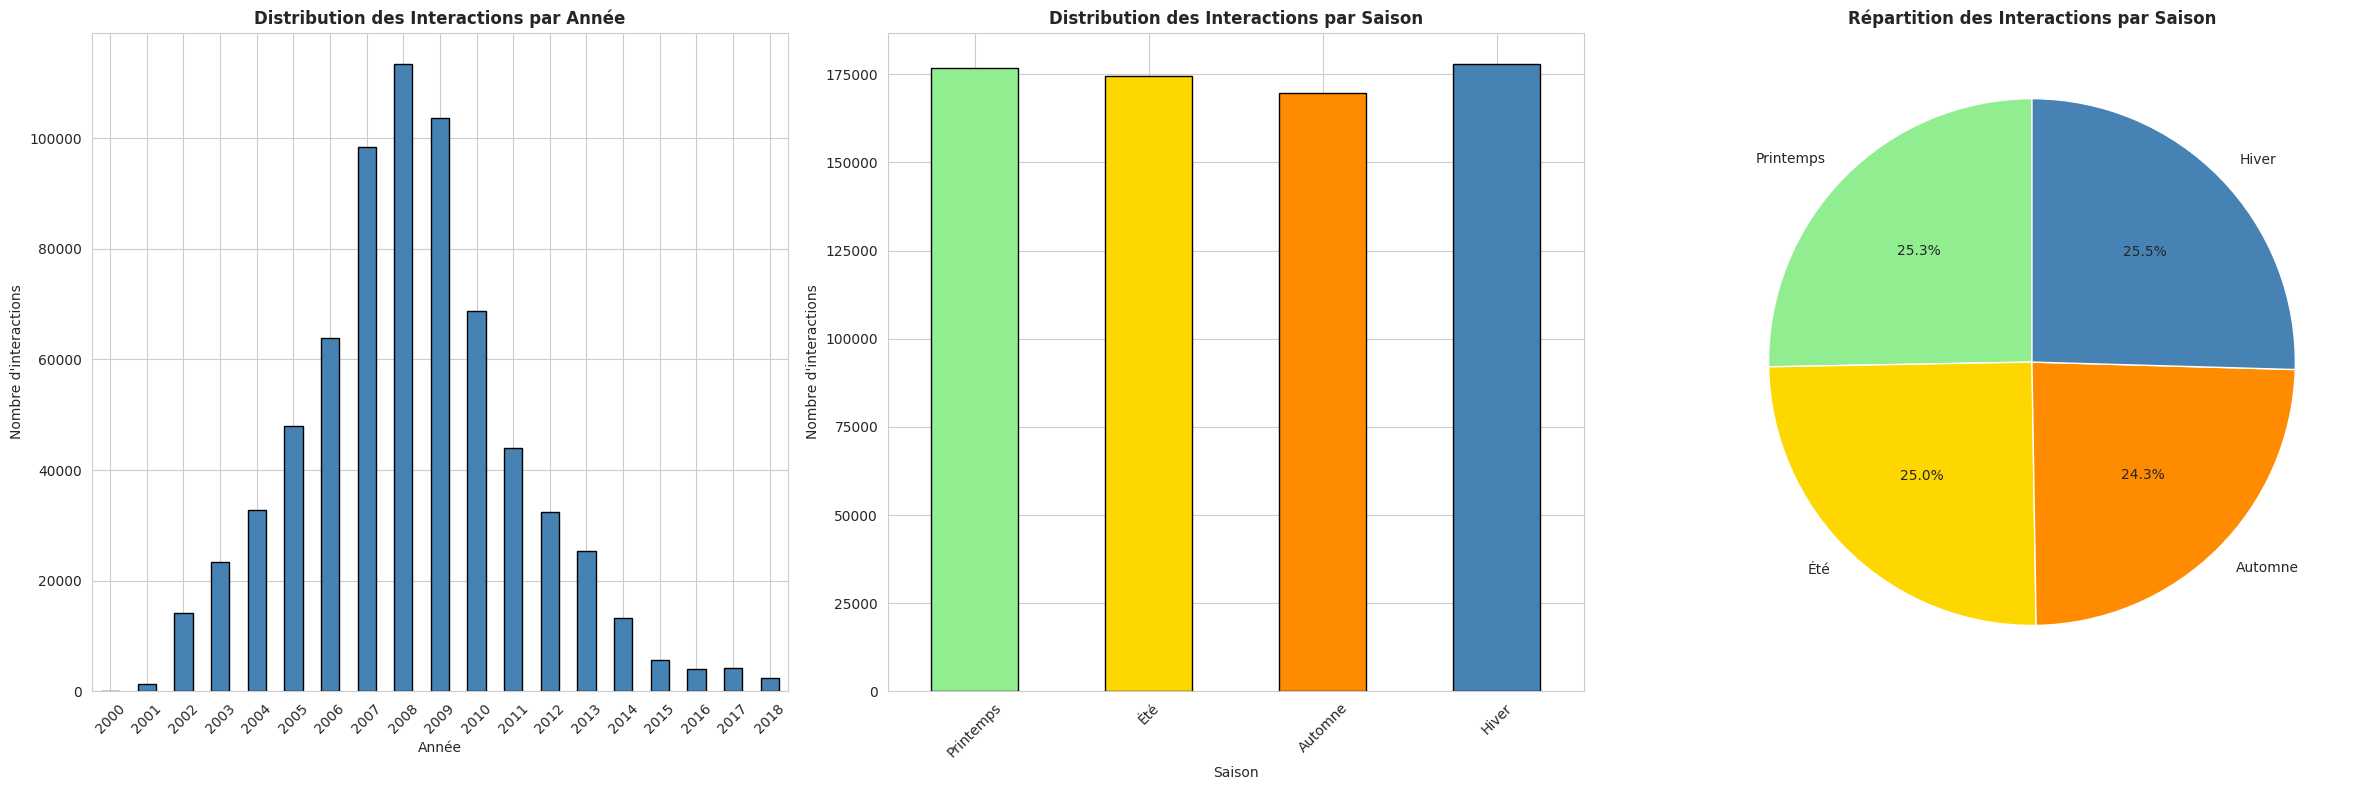


📈 INSIGHTS TEMPORELS:
   • Année la plus active: 2008 (113,353 interactions)
   • Année la moins active: 2000 (18 interactions)
   • Saison la plus active: Hiver (177,875 interactions)
   • Saison la moins active: Automne (169,808 interactions)


In [8]:
# Parse dates et extraire année, mois, saison
interactions_train['date_parsed'] = pd.to_datetime(interactions_train['date'])
interactions_train['year'] = interactions_train['date_parsed'].dt.year
interactions_train['month'] = interactions_train['date_parsed'].dt.month

# Définir les saisons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Hiver'
    elif month in [3, 4, 5]:
        return 'Printemps'
    elif month in [6, 7, 8]:
        return 'Été'
    else:  # 9, 10, 11
        return 'Automne'

interactions_train['season'] = interactions_train['month'].apply(get_season)

print("=" * 80)
print("ANALYSE TEMPORELLE - INTERACTIONS")
print("=" * 80)

print(f"\n📅 PÉRIODE COUVERTE:")
print(f"   • Première interaction: {interactions_train['date_parsed'].min()}")
print(f"   • Dernière interaction: {interactions_train['date_parsed'].max()}")
print(f"   • Nombre de jours: {(interactions_train['date_parsed'].max() - interactions_train['date_parsed'].min()).days:,}")

# Visualisations - Distribution temporelle des interactions
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# 1. Interactions par année - Bar chart
year_counts = interactions_train['year'].value_counts().sort_index()
year_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution des Interactions par Année', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre d\'interactions')
axes[0].tick_params(axis='x', rotation=45)


# 4. Interactions par saison - Bar chart
season_order = ['Printemps', 'Été', 'Automne', 'Hiver']
season_counts = interactions_train['season'].value_counts().reindex(season_order)
season_counts.plot(kind='bar', ax=axes[1], color=['#90EE90', '#FFD700', '#FF8C00', '#4682B4'], edgecolor='black')
axes[1].set_title('Distribution des Interactions par Saison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Saison')
axes[1].set_ylabel('Nombre d\'interactions')
axes[1].tick_params(axis='x', rotation=45)

# 5. Interactions par saison - Pie chart
colors_pie = ['#90EE90', '#FFD700', '#FF8C00', '#4682B4']
season_counts.plot(kind='pie', ax=axes[2], autopct='%1.1f%%', startangle=90, 
                   colors=colors_pie, labels=season_order)
axes[2].set_title('Répartition des Interactions par Saison', fontsize=12, fontweight='bold')
axes[2].set_ylabel('')


plt.tight_layout()
plt.show()

# Insights supplémentaires
print(f"\n📈 INSIGHTS TEMPORELS:")
print(f"   • Année la plus active: {year_counts.idxmax()} ({year_counts.max():,} interactions)")
print(f"   • Année la moins active: {year_counts.idxmin()} ({year_counts.min():,} interactions)")
print(f"   • Saison la plus active: {season_counts.idxmax()} ({season_counts.max():,} interactions)")
print(f"   • Saison la moins active: {season_counts.idxmin()} ({season_counts.min():,} interactions)")


## 4. EDA - Recettes (RAW) - Structure & Colonnes

In [9]:
print("=" * 80)
print("EDA - RECETTES (RAW)")
print("=" * 80)

print(f"\n INFO GÉNÉRALE:")
print(recipes.info())

print(f"\n PREMIÈRES LIGNES:")
print(recipes.head())

print(f"\n STATISTIQUES:")
print(recipes.describe())

print(f"\n VALEURS MANQUANTES:")
print(recipes.isnull().sum())

EDA - RECETTES (RAW)

 INFO GÉNÉRALE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   name            231636 non-null  object
 1   id              231637 non-null  int64 
 2   minutes         231637 non-null  int64 
 3   contributor_id  231637 non-null  int64 
 4   submitted       231637 non-null  object
 5   tags            231637 non-null  object
 6   nutrition       231637 non-null  object
 7   n_steps         231637 non-null  int64 
 8   steps           231637 non-null  object
 9   description     226658 non-null  object
 10  ingredients     231637 non-null  object
 11  n_ingredients   231637 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 21.2+ MB
None

 PREMIÈRES LIGNES:
                                         name      id  minutes  \
0  arriba   baked winter squash mexican style  137739       55   
1            

In [10]:
print(f"\n ANALYSE DE LA COLONNE 'nutrition' (CRITIQUE!):")
print(f"   Type: {type(recipes['nutrition'].iloc[0])}")
print(f"   Valeur exemple: {recipes['nutrition'].iloc[0]}")
print(f"\n   Exemples de 5 premières recettes:")
for i in range(3):
    print(f"   [{i}] {recipes['nutrition'].iloc[i]}")

print(f"\n ANALYSE DE LA COLONNE 'tags' (CRITIQUE!):")
print(f"   Type: {type(recipes['tags'].iloc[0])}")
print(f"   Valeur exemple: {recipes['tags'].iloc[0]}")
print(f"\n   Exemples de 5 premières recettes:")
for i in range(3):
    print(f"   [{i}] {recipes['tags'].iloc[i]}")

print(f"\n ANALYSE DE LA COLONNE 'ingredients' (CRITIQUE!):")
print(f"   Type: {type(recipes['ingredients'].iloc[0])}")
print(f"   Valeur exemple: {recipes['ingredients'].iloc[0]}")
print(f"\n   Exemples de 5 premières recettes:")
for i in range(3):
    print(f"   [{i}] {recipes['ingredients'].iloc[i]}")

print(f"\n ANALYSE DE LA COLONNE 'steps' (CRITIQUE!):")
print(f"   Type: {type(recipes['steps'].iloc[0])}")
print(f"   Valeur exemple: {recipes['steps'].iloc[0]}")
print(f"\n   Exemples de 5 premières recettes:")
for i in range(3):
    print(f"   [{i}] {recipes['steps'].iloc[i]}")


 ANALYSE DE LA COLONNE 'nutrition' (CRITIQUE!):
   Type: <class 'str'>
   Valeur exemple: [51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]

   Exemples de 5 premières recettes:
   [0] [51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]
   [1] [173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]
   [2] [269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]

 ANALYSE DE LA COLONNE 'tags' (CRITIQUE!):
   Type: <class 'str'>
   Valeur exemple: ['60-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'preparation', 'occasion', 'north-american', 'side-dishes', 'vegetables', 'mexican', 'easy', 'fall', 'holiday-event', 'vegetarian', 'winter', 'dietary', 'christmas', 'seasonal', 'squash']

   Exemples de 5 premières recettes:
   [0] ['60-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'preparation', 'occasion', 'north-american', 'side-dishes', 'vegetables', 'mexican', 'easy', 'fall', 'holiday-event', 'vegetarian', 'winter', 'dietary', 'christmas', 'seasonal', 'squash']
   [1] ['30-minutes-or-l

### 4.3 Visualisations - Colonnes numériques (minutes, n_steps, n_ingredients, calories)

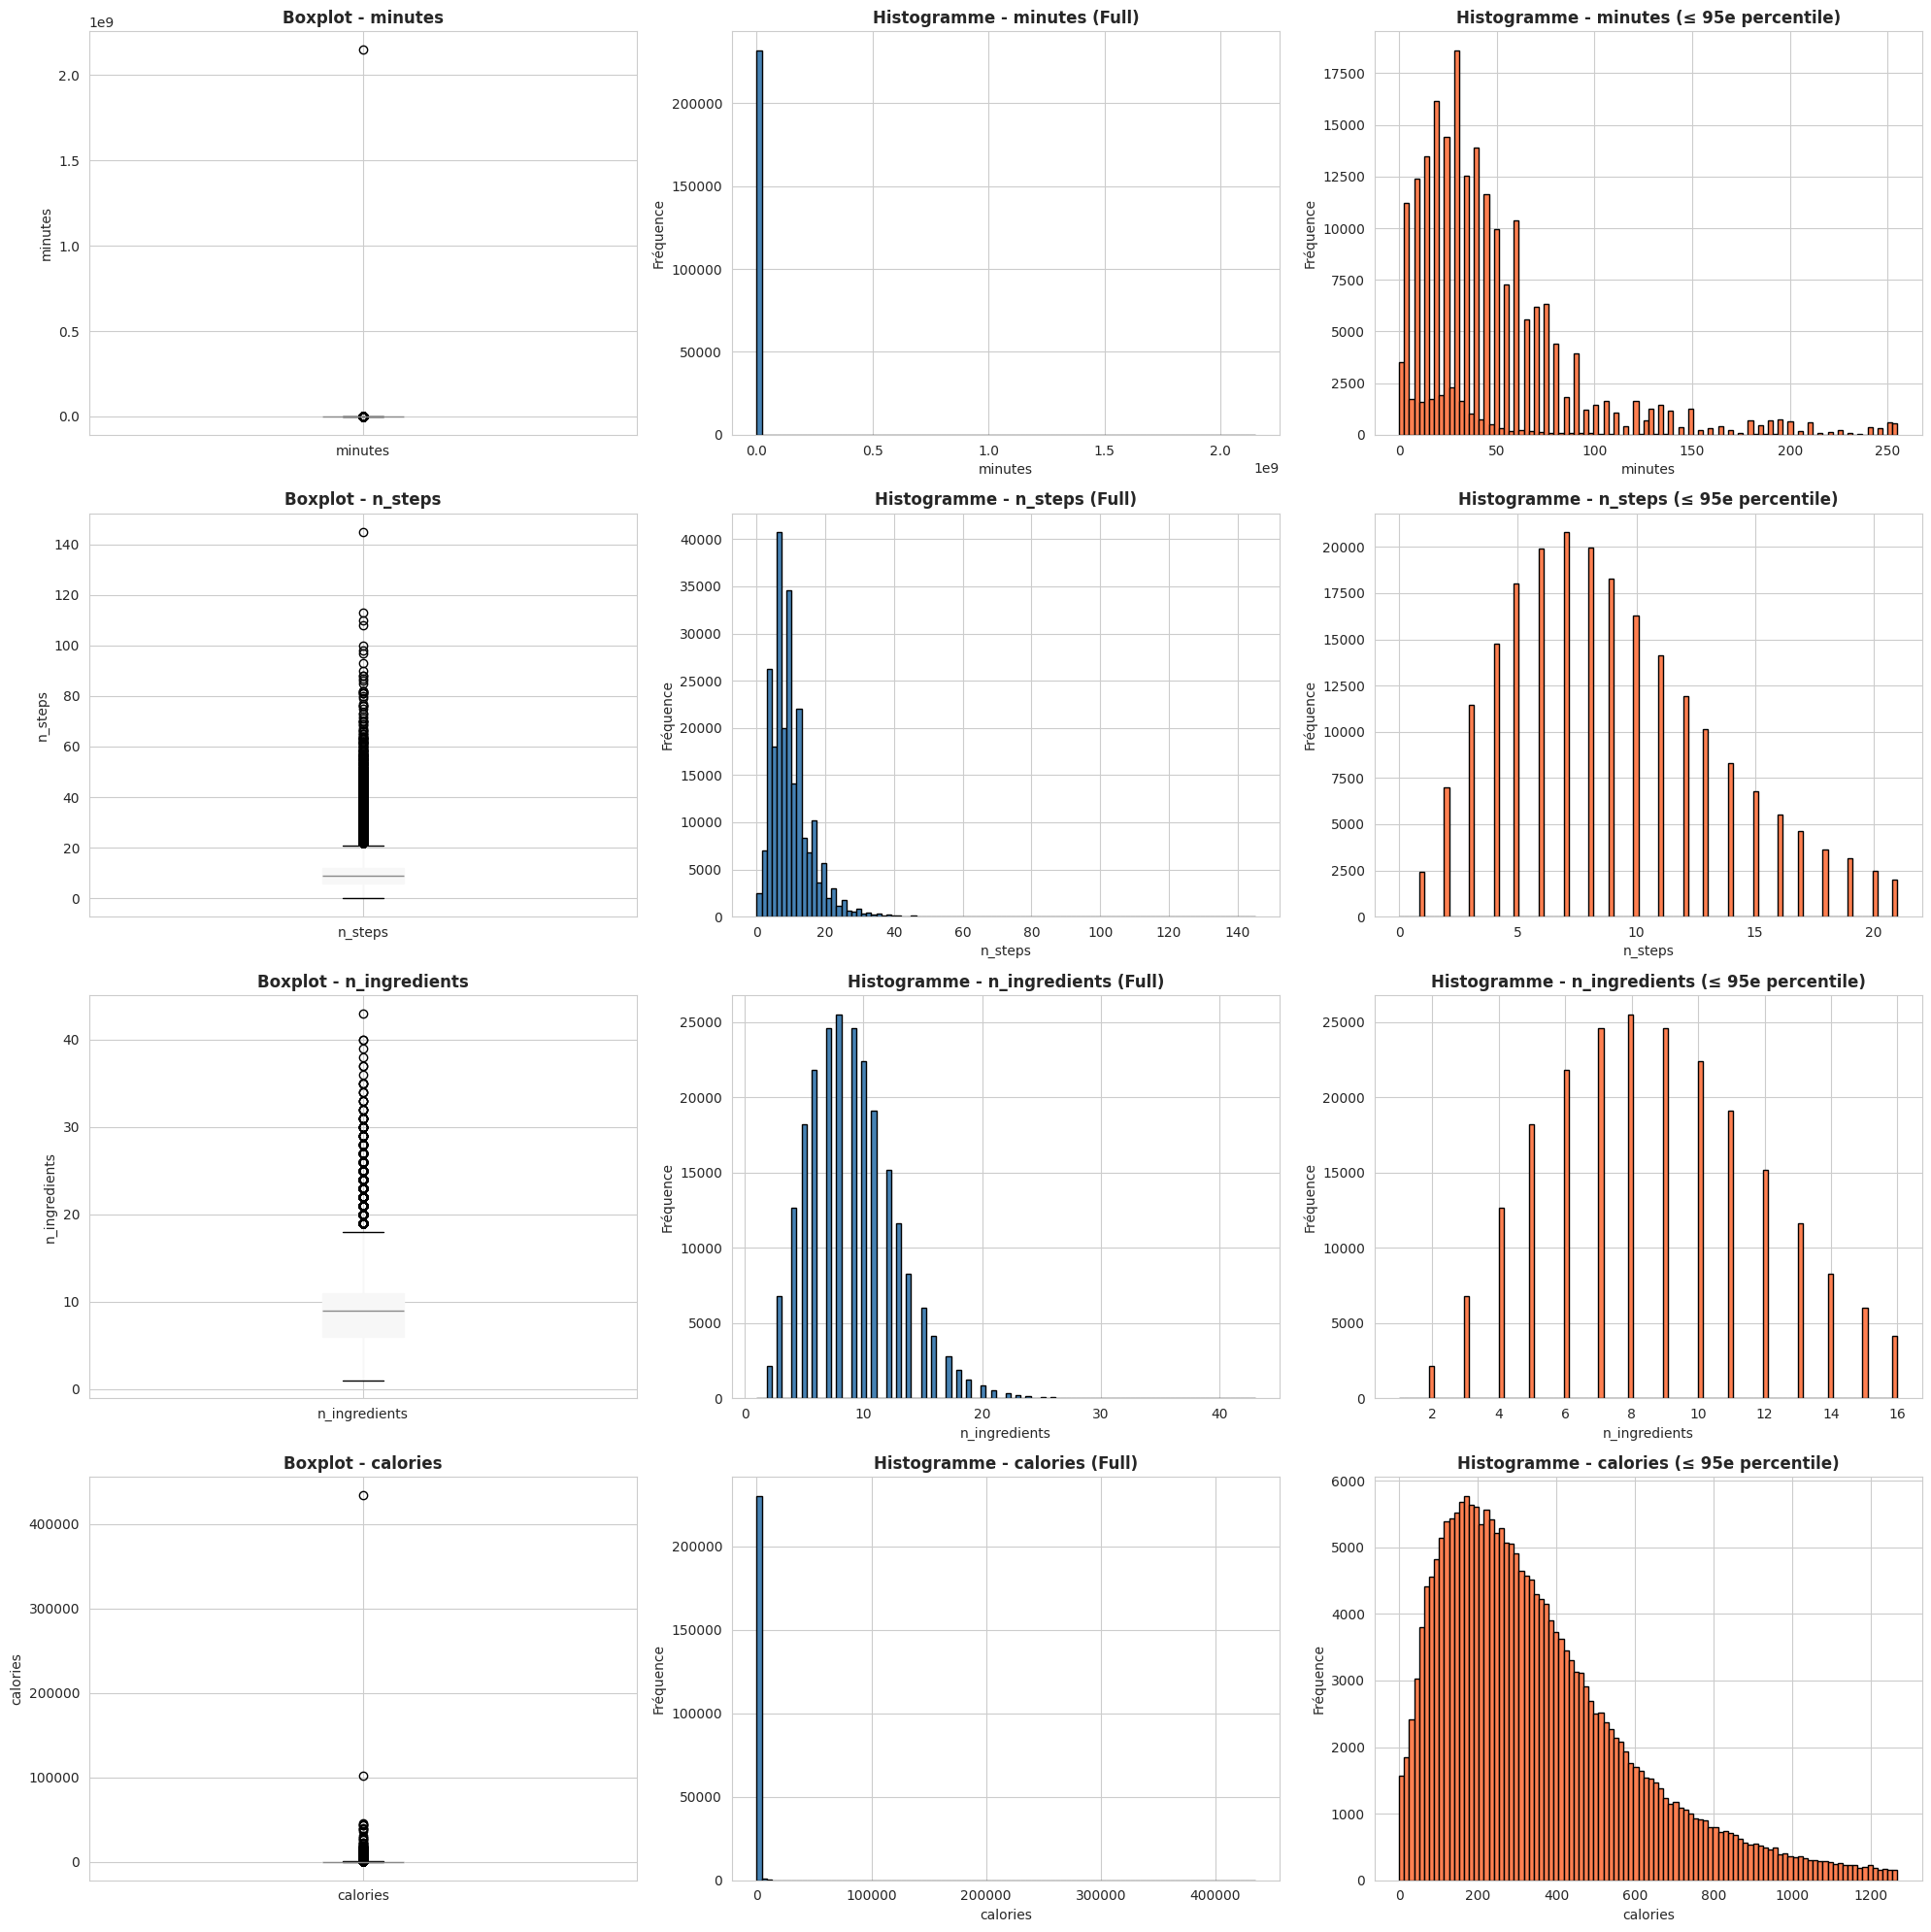


 STATISTIQUES DÉTAILLÉES - Colonnes numériques:
            minutes        n_steps  n_ingredients       calories
count  2.316370e+05  231637.000000  231637.000000  231637.000000
mean   9.398546e+03       9.765499       9.051153     473.942425
std    4.461963e+06       5.995128       3.734796    1189.711374
min    0.000000e+00       0.000000       1.000000       0.000000
25%    2.000000e+01       6.000000       6.000000     174.400000
50%    4.000000e+01       9.000000       9.000000     313.400000
75%    6.500000e+01      12.000000      11.000000     519.700000
max    2.147484e+09     145.000000      43.000000  434360.200000

 VALEURS MANQUANTES:
   minutes             :      0 valeurs manquantes (0.00%)
   n_steps             :      0 valeurs manquantes (0.00%)
   n_ingredients       :      0 valeurs manquantes (0.00%)
   calories            :      0 valeurs manquantes (0.00%)

 OUTLIERS (> 95e percentile):
   minutes             : 95e percentile =    255.0, outliers = 11,463 (4.9%)


In [11]:
# Fonction pour parser les colonnes de type liste (nutrition, tags, etc.)
def parse_list_col(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except:
        return []

# Parser la colonne nutrition pour extraire les calories (index 0)
recipes['nutrition_parsed'] = recipes['nutrition'].apply(parse_list_col)
recipes['calories'] = recipes['nutrition_parsed'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)

# Visualisations APPROFONDIES - Recettes (colonnes numériques + calories)
numeric_recipe_cols = ['minutes', 'n_steps', 'n_ingredients', 'calories']

fig, axes = plt.subplots(4, 3, figsize=(20, 20))

for idx, col in enumerate(numeric_recipe_cols):
    # Boxplot
    recipes.boxplot(column=col, ax=axes[idx, 0], patch_artist=True)
    axes[idx, 0].set_title(f'Boxplot - {col}', fontsize=12, fontweight='bold')
    axes[idx, 0].set_ylabel(col)
    
    # Histogramme (full range)
    recipes[col].hist(bins=100, ax=axes[idx, 1], color='steelblue', edgecolor='black')
    axes[idx, 1].set_title(f'Histogramme - {col} (Full)', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel(col)
    axes[idx, 1].set_ylabel('Fréquence')
    
    # Histogramme (95e percentile pour voir les détails)
    p95 = recipes[col].quantile(0.95)
    recipes[recipes[col] <= p95][col].hist(bins=100, ax=axes[idx, 2], color='coral', edgecolor='black')
    axes[idx, 2].set_title(f'Histogramme - {col} (≤ 95e percentile)', fontsize=12, fontweight='bold')
    axes[idx, 2].set_xlabel(col)
    axes[idx, 2].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

print(f"\n STATISTIQUES DÉTAILLÉES - Colonnes numériques:")
print(recipes[numeric_recipe_cols].describe())

print(f"\n VALEURS MANQUANTES:")
for col in numeric_recipe_cols:
    n_missing = recipes[col].isnull().sum()
    print(f"   {col:<20}: {n_missing:>6,} valeurs manquantes ({100*n_missing/len(recipes):.2f}%)")

print(f"\n OUTLIERS (> 95e percentile):")
for col in numeric_recipe_cols:
    p95 = recipes[col].quantile(0.95)
    n_outliers = (recipes[col] > p95).sum()
    print(f"   {col:<20}: 95e percentile = {p95:>8.1f}, outliers = {n_outliers:>6,} ({100*n_outliers/len(recipes):.1f}%)")

## 5. EDA - Nutrition Complète (toutes les colonnes)

In [12]:
print("=" * 80)
print("EDA - NUTRITION COMPLÈTE (7 COLONNES)")
print("=" * 80)

# Extraire toutes les colonnes nutrition
recipes['total_fat'] = recipes['nutrition_parsed'].apply(lambda x: x[1] if len(x) > 1 else np.nan)
recipes['sugar'] = recipes['nutrition_parsed'].apply(lambda x: x[2] if len(x) > 2 else np.nan)
recipes['sodium'] = recipes['nutrition_parsed'].apply(lambda x: x[3] if len(x) > 3 else np.nan)
recipes['protein'] = recipes['nutrition_parsed'].apply(lambda x: x[4] if len(x) > 4 else np.nan)
recipes['saturated_fat'] = recipes['nutrition_parsed'].apply(lambda x: x[5] if len(x) > 5 else np.nan)
recipes['carbohydrates'] = recipes['nutrition_parsed'].apply(lambda x: x[6] if len(x) > 6 else np.nan)

nutrition_cols = ['calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']

print(f"\n📊 STATISTIQUES NUTRITION:")
print(recipes[nutrition_cols].describe())

print(f"\n📉 VALEURS MANQUANTES:")
for col in nutrition_cols:
    missing = recipes[col].isnull().sum()
    print(f"   {col:<20}: {missing:>6,} ({100*missing/len(recipes):>5.2f}%)")

print(f"\n⚠️  OUTLIERS (> 99e percentile):")
for col in nutrition_cols:
    p99 = recipes[col].quantile(0.99)
    max_val = recipes[col].max()
    n_outliers = (recipes[col] > p99).sum()
    print(f"   {col:<20}: p99={p99:>8.1f}, max={max_val:>10.1f}, outliers={n_outliers:>5,}")

EDA - NUTRITION COMPLÈTE (7 COLONNES)

📊 STATISTIQUES NUTRITION:
            calories     total_fat          sugar         sodium  \
count  231637.000000  231637.00000  231637.000000  231637.000000   
mean      473.942425      36.08070      84.296865      30.147485   
std      1189.711374      77.79884     800.080897     131.961589   
min         0.000000       0.00000       0.000000       0.000000   
25%       174.400000       8.00000       9.000000       5.000000   
50%       313.400000      20.00000      25.000000      14.000000   
75%       519.700000      41.00000      68.000000      33.000000   
max    434360.200000   17183.00000  362729.000000   29338.000000   

            protein  saturated_fat  carbohydrates  
count  231637.00000  231637.000000  231637.000000  
mean       34.68186      45.589150      15.560403  
std        58.47248      98.235758      81.824560  
min         0.00000       0.000000       0.000000  
25%         7.00000       7.000000       4.000000  
50%       

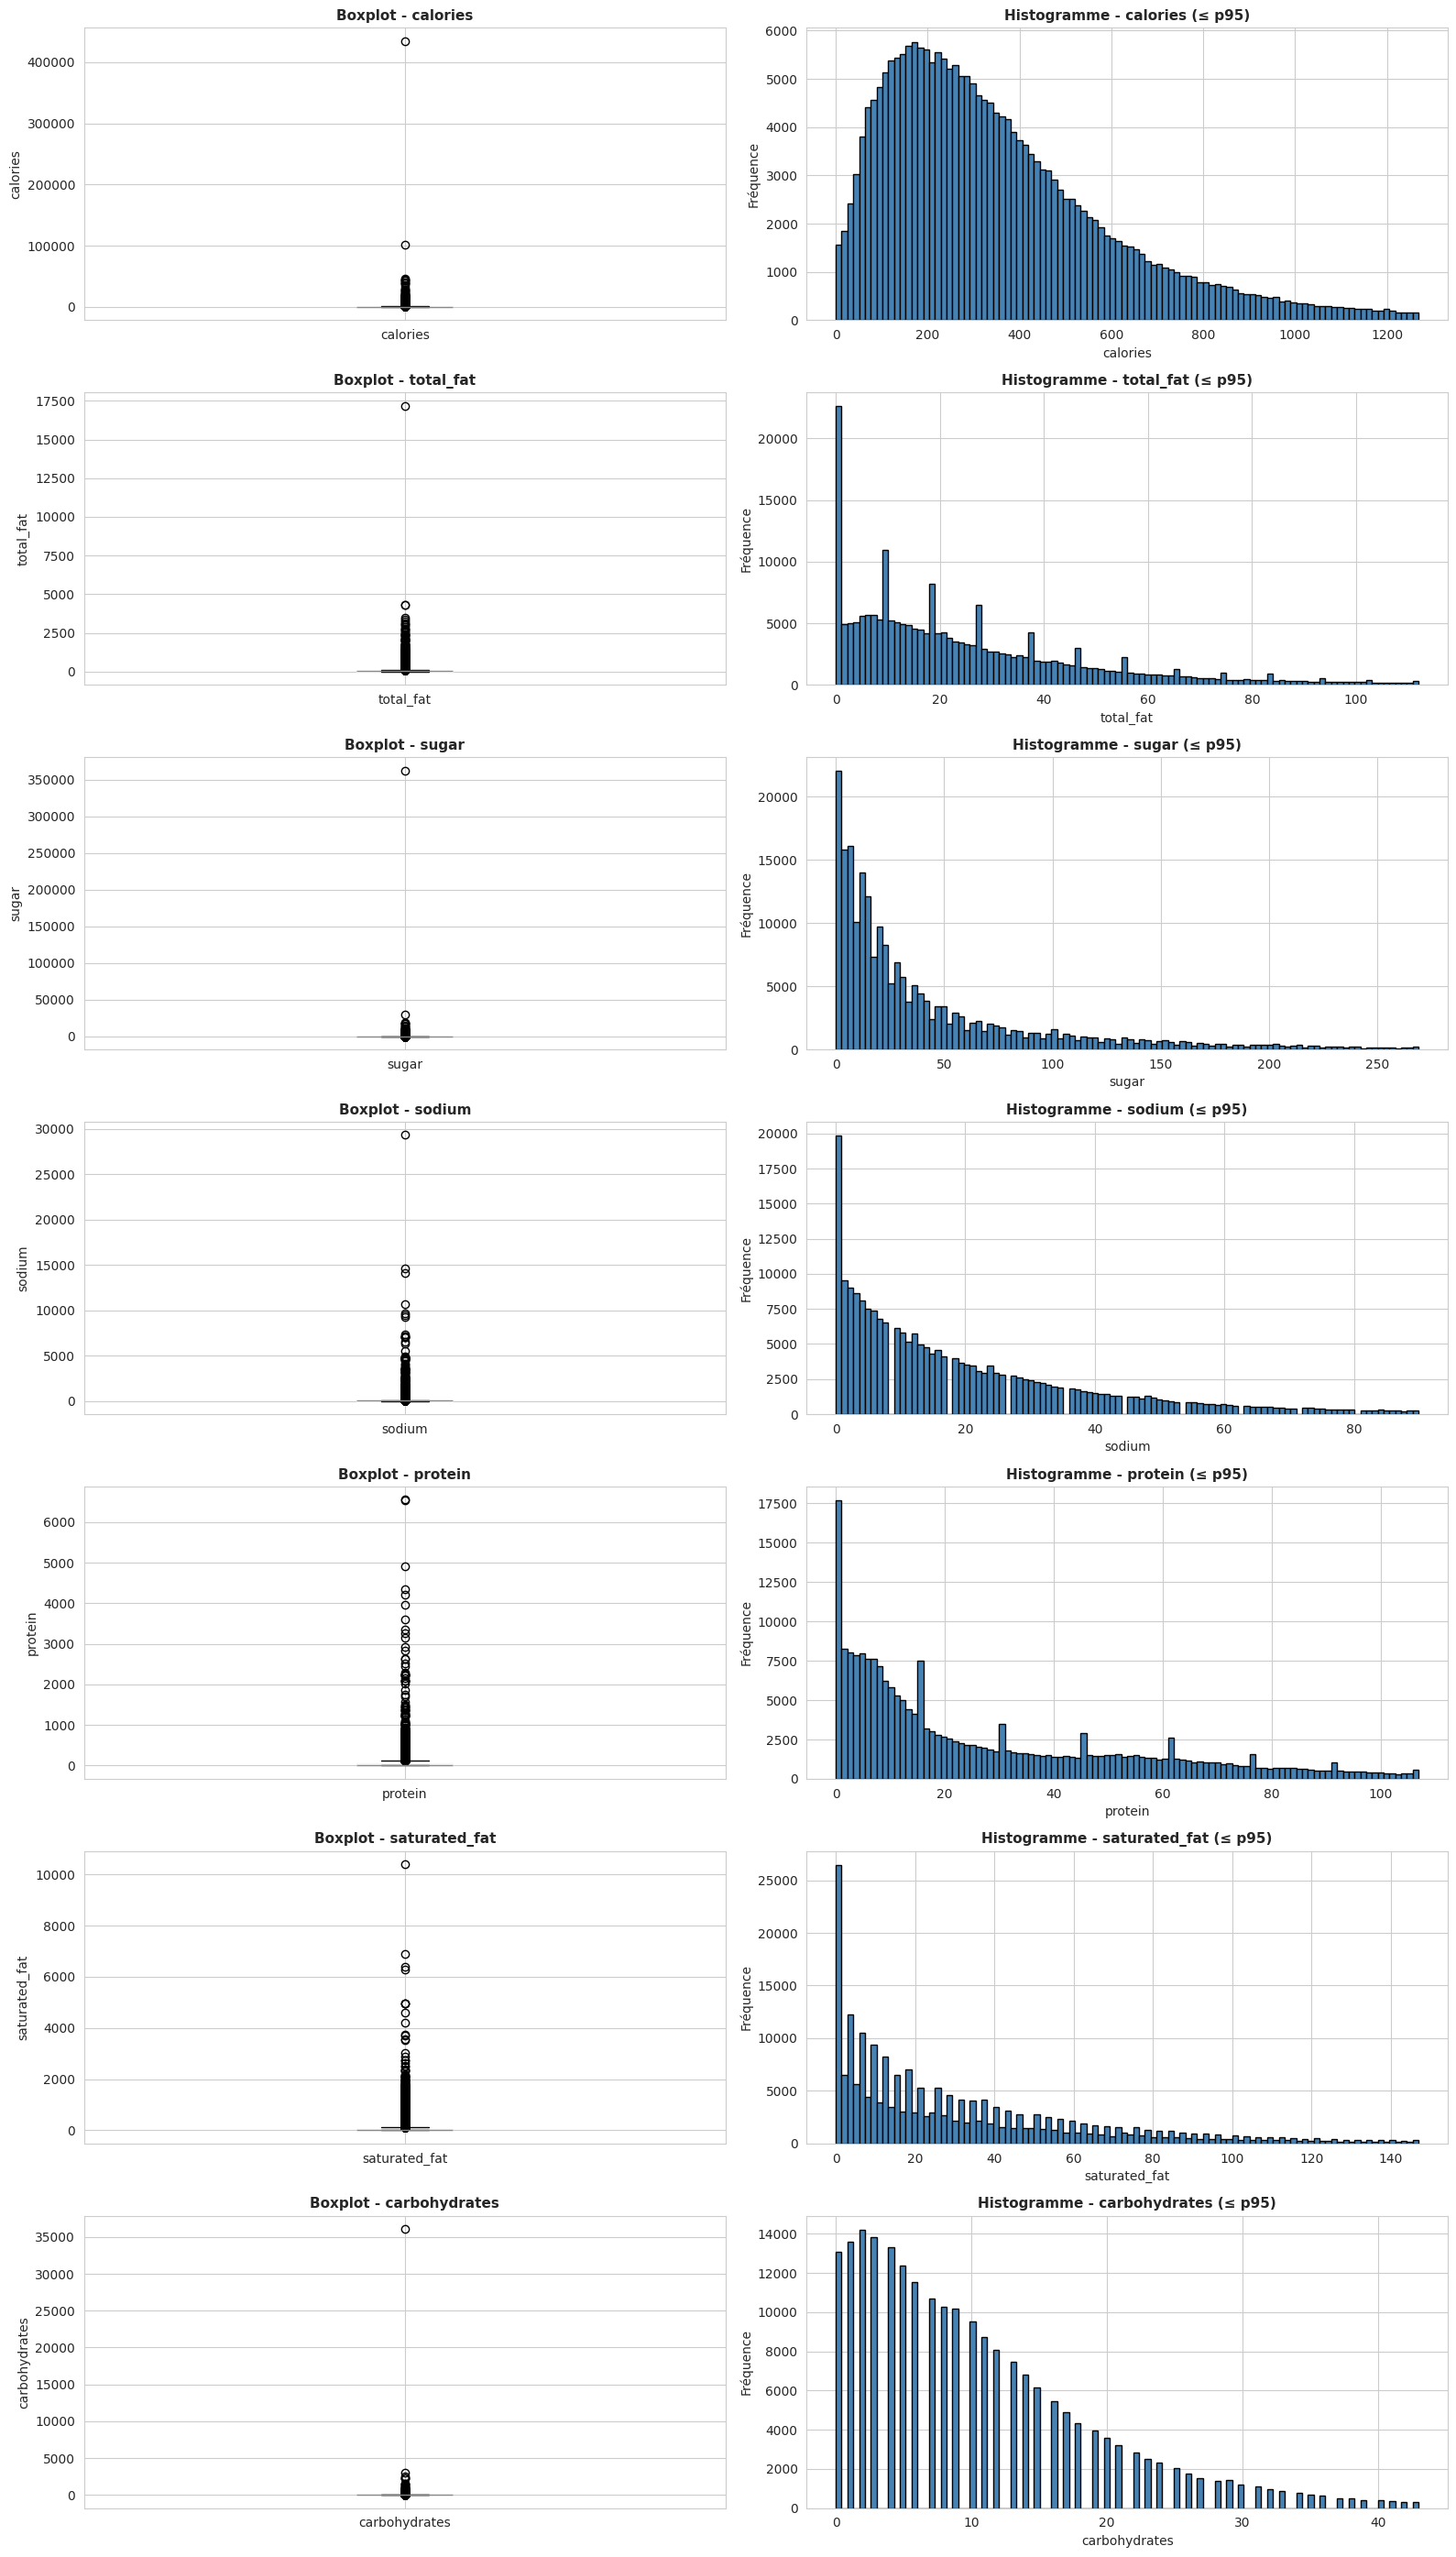

In [13]:
# Visualisations Nutrition - Boxplots et Histogrammes
fig, axes = plt.subplots(7, 2, figsize=(16, 28))

for idx, col in enumerate(nutrition_cols):
    # Boxplot
    recipes.boxplot(column=col, ax=axes[idx, 0], patch_artist=True)
    axes[idx, 0].set_title(f'Boxplot - {col}', fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel(col)
    
    # Histogramme (95e percentile)
    p95 = recipes[col].quantile(0.95)
    recipes[recipes[col] <= p95][col].hist(bins=100, ax=axes[idx, 1], color='steelblue', edgecolor='black')
    axes[idx, 1].set_title(f'Histogramme - {col} (≤ p95)', fontsize=11, fontweight='bold')
    axes[idx, 1].set_xlabel(col)
    axes[idx, 1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

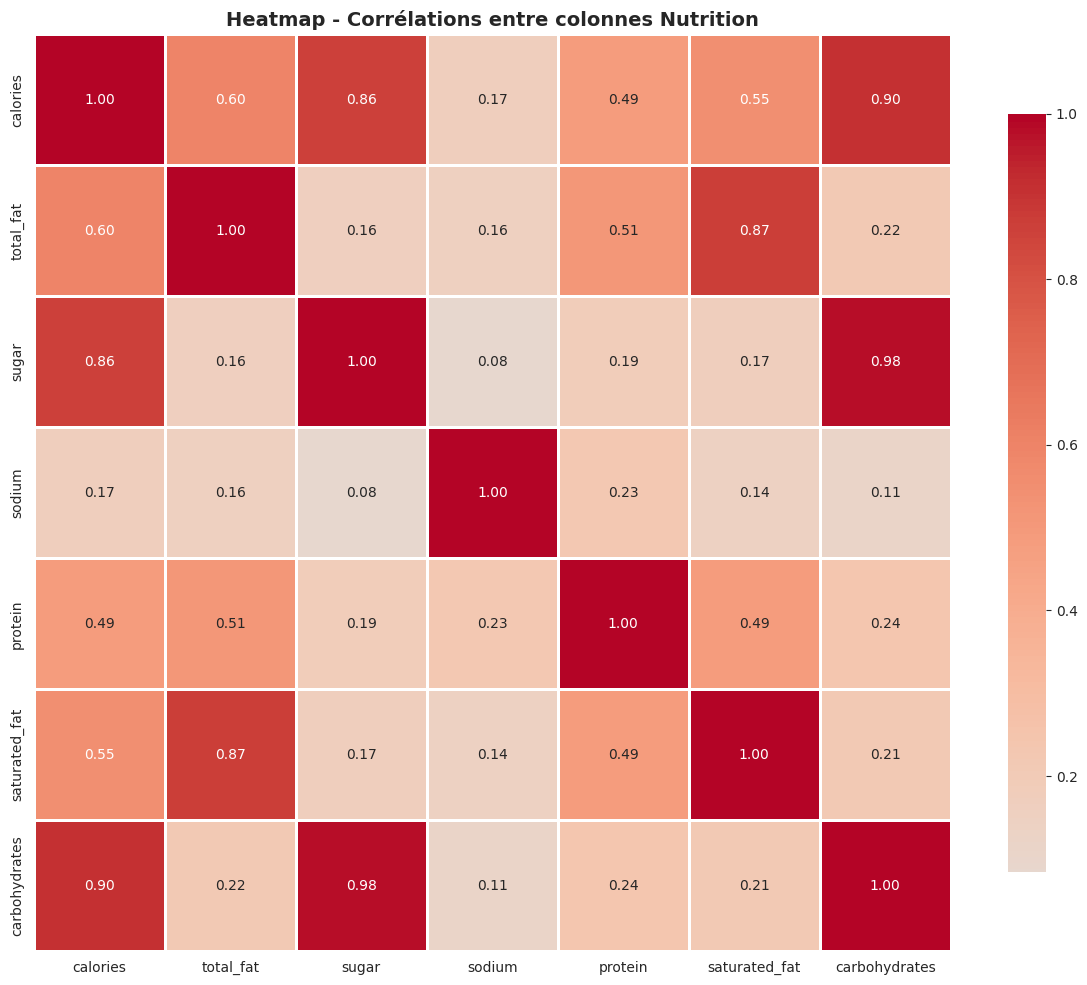


🔗 CORRÉLATIONS FORTES (|r| > 0.7):
   calories             ↔ sugar               :  0.864
   calories             ↔ carbohydrates       :  0.904
   total_fat            ↔ saturated_fat       :  0.871
   sugar                ↔ carbohydrates       :  0.981


In [14]:
# Heatmap corrélations nutrition
nutrition_corr = recipes[nutrition_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(nutrition_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Heatmap - Corrélations entre colonnes Nutrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n🔗 CORRÉLATIONS FORTES (|r| > 0.7):")
for i in range(len(nutrition_cols)):
    for j in range(i+1, len(nutrition_cols)):
        corr_val = nutrition_corr.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"   {nutrition_cols[i]:<20} ↔ {nutrition_cols[j]:<20}: {corr_val:>6.3f}")

## 6. EDA - Tags & Ingredients

In [15]:
print("=" * 80)
print("EDA - TAGS & INGREDIENTS")
print("=" * 80)

# Analyse TAGS
recipes['tags_parsed'] = recipes['tags'].apply(parse_list_col)
recipes['n_tags'] = recipes['tags_parsed'].apply(len)

all_tags = []
for tag_list in recipes['tags_parsed']:
    all_tags.extend(tag_list)
tag_counts = Counter(all_tags)

print(f"\n🏷️  TAGS:")
print(f"   • Total tags uniques: {len(tag_counts):,}")
print(f"   • Total tags (avec répétitions): {len(all_tags):,}")
print(f"   • Tags par recette (moyenne): {recipes['n_tags'].mean():.1f}")
print(f"   • Tags par recette (médiane): {recipes['n_tags'].median():.0f}")

# Analyse INGREDIENTS
recipes['ingredients_parsed'] = recipes['ingredients'].apply(parse_list_col)
recipes['n_ingredients_check'] = recipes['ingredients_parsed'].apply(len)

all_ingredients = []
for ing_list in recipes['ingredients_parsed']:
    all_ingredients.extend(ing_list)
ingredient_counts = Counter(all_ingredients)

print(f"\n🥕 INGREDIENTS:")
print(f"   • Total ingredients uniques: {len(ingredient_counts):,}")
print(f"   • Total ingredients (avec répétitions): {len(all_ingredients):,}")
print(f"   • Ingredients par recette (moyenne): {recipes['n_ingredients_check'].mean():.1f}")
print(f"   • Ingredients par recette (médiane): {recipes['n_ingredients_check'].median():.0f}")

print(f"\n🏆 TOP 30 TAGS:")
for tag, count in tag_counts.most_common(30):
    pct = 100 * count / len(recipes)
    print(f"   {tag:<40} {count:>7,} ({pct:>5.1f}%)")

print(f"\n🏆 TOP 30 INGREDIENTS:")
for ing, count in ingredient_counts.most_common(30):
    pct = 100 * count / len(recipes)
    print(f"   {ing:<40} {count:>7,} ({pct:>5.1f}%)")

EDA - TAGS & INGREDIENTS

🏷️  TAGS:
   • Total tags uniques: 552
   • Total tags (avec répétitions): 4,141,688
   • Tags par recette (moyenne): 17.9
   • Tags par recette (médiane): 17

🥕 INGREDIENTS:
   • Total ingredients uniques: 14,942
   • Total ingredients (avec répétitions): 2,096,582
   • Ingredients par recette (moyenne): 9.1
   • Ingredients par recette (médiane): 9

🏆 TOP 30 TAGS:
   preparation                              230,546 ( 99.5%)
   time-to-make                             225,326 ( 97.3%)
   course                                   218,148 ( 94.2%)
   main-ingredient                          170,446 ( 73.6%)
   dietary                                  165,091 ( 71.3%)
   easy                                     126,062 ( 54.4%)
   occasion                                 114,145 ( 49.3%)
   cuisine                                   91,165 ( 39.4%)
   low-in-something                          85,776 ( 37.0%)
   main-dish                                 71,786 ( 31

In [16]:
tags_uniques = list(set(all_tags))
print(f"   • Liste des tags uniques: {tags_uniques}")

   • Liste des tags uniques: ['', '1-day-or-more', 'tempeh', 'english', 'irish', 'rosh-hashanah', 'chicken-livers', 'tomatoes', 'kid-friendly', 'pineapple', 'libyan', 'burgers', 'elk', 'artichoke', 'heirloom-historical-recipes', 'ramadan', 'pies', 'beginner-cook', 'american', 'cake-fillings-and-frostings', 'memorial-day', 'water-bath', 'time-to-make', 'dairy-free', 'hidden-valley-ranch', 'to-go', 'cod', 'desserts', 'clams', 'spicy', 'austrian', 'octopus', 'cinco-de-mayo', 'strawberries', 'italian', 'sandwiches', 'carrots', 'sole-and-flounder', 'roast', 'passover', 'caribbean', 'blueberries', 'mushrooms', 'malaysian', 'perch', 'turkey', 'pasta-rice-and-grains', 'sweet-sauces', 'main-dish', 'cooking-mixes', 'micro-melanesia', 'yeast', 'gelatin', 'low-saturated-fat', 'yams-sweet-potatoes', 'ground-beef', 'marinara-sauce', 'cocktails', 'cheesecake', 'heirloom-historical', 'potluck', 'vegetables', 'breads', 'stews-poultry', 'quick-breads', 'pasta', 'californian', 'main-dish-pasta', 'german'

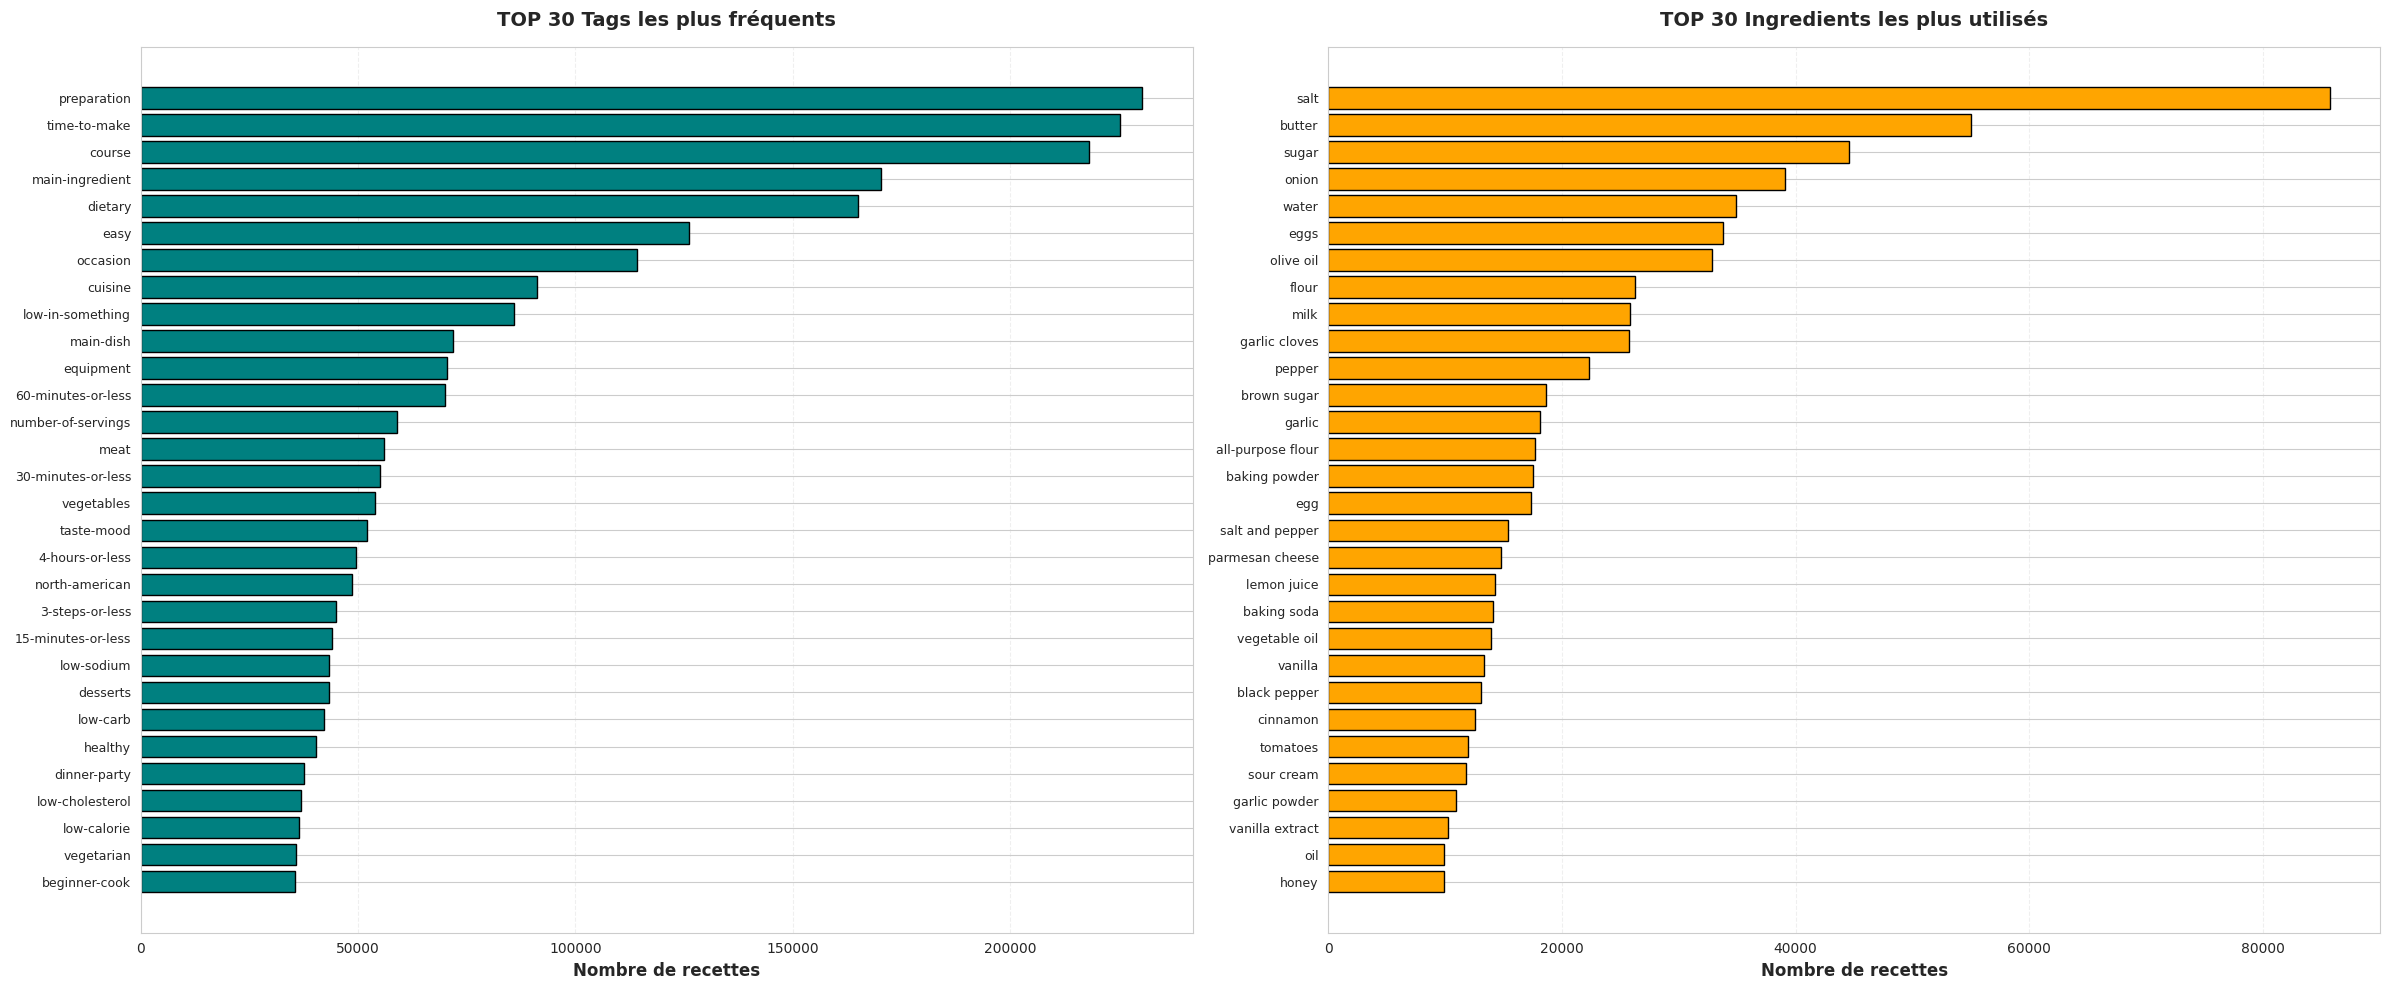

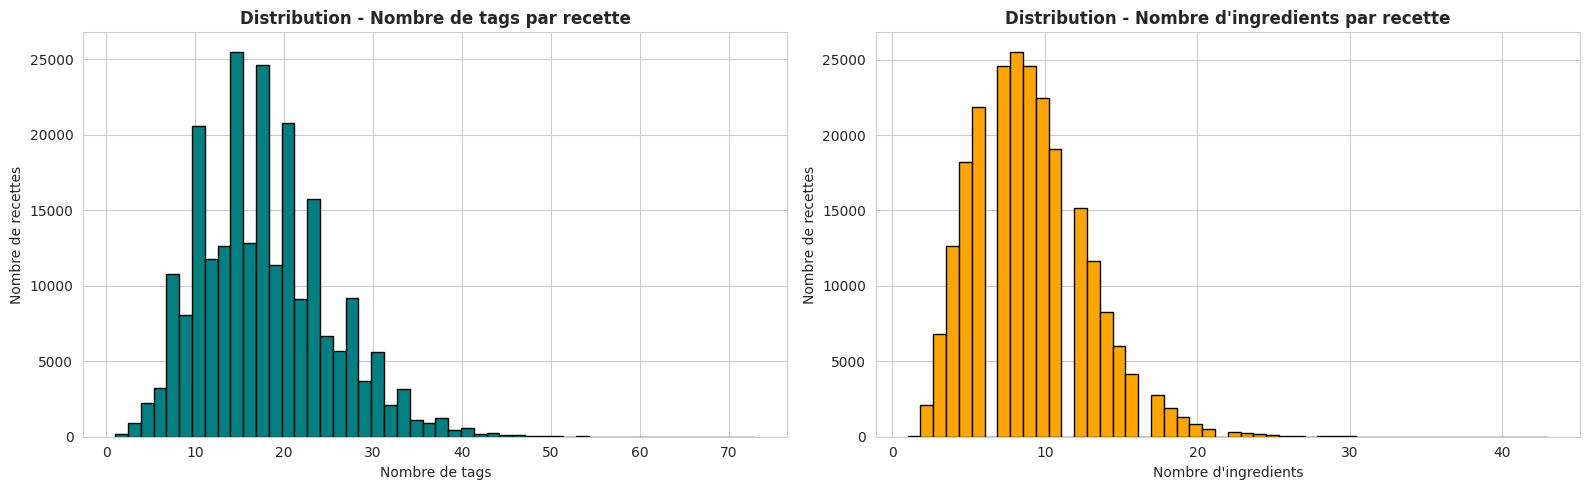

In [17]:
# Visualisations Tags & Ingredients
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# TOP 30 Tags
top_30_tags = tag_counts.most_common(30)
tag_names = [t[0] for t in top_30_tags]
tag_vals = [t[1] for t in top_30_tags]

axes[0].barh(range(len(tag_names)), tag_vals, color='teal', edgecolor='black')
axes[0].set_yticks(range(len(tag_names)))
axes[0].set_yticklabels(tag_names, fontsize=9)
axes[0].set_xlabel('Nombre de recettes', fontsize=12, fontweight='bold')
axes[0].set_title('TOP 30 Tags les plus fréquents', fontsize=14, fontweight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# TOP 30 Ingredients
top_30_ingredients = ingredient_counts.most_common(30)
ing_names = [t[0] for t in top_30_ingredients]
ing_vals = [t[1] for t in top_30_ingredients]

axes[1].barh(range(len(ing_names)), ing_vals, color='orange', edgecolor='black')
axes[1].set_yticks(range(len(ing_names)))
axes[1].set_yticklabels(ing_names, fontsize=9)
axes[1].set_xlabel('Nombre de recettes', fontsize=12, fontweight='bold')
axes[1].set_title('TOP 30 Ingredients les plus utilisés', fontsize=14, fontweight='bold', pad=15)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Distribution nombre de tags/ingredients par recette
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

recipes['n_tags'].hist(bins=50, ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Distribution - Nombre de tags par recette', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nombre de tags')
axes[0].set_ylabel('Nombre de recettes')

recipes['n_ingredients_check'].hist(bins=50, ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Distribution - Nombre d\'ingredients par recette', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre d\'ingredients')
axes[1].set_ylabel('Nombre de recettes')

plt.tight_layout()
plt.show()

## 7. EDA - Utilisateurs (PP_users.csv)

In [18]:
print("=" * 80)
print("EDA - UTILISATEURS")
print("=" * 80)

print(f"\nINFO GÉNÉRALE:")
print(users.columns.tolist())
print(users.info())
print(users.describe())

print(f"\nPREMIÈRES LIGNES:")
print(users.head())


EDA - UTILISATEURS

INFO GÉNÉRALE:
['u', 'techniques', 'items', 'n_items', 'ratings', 'n_ratings']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25076 entries, 0 to 25075
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   u           25076 non-null  int64 
 1   techniques  25076 non-null  object
 2   items       25076 non-null  object
 3   n_items     25076 non-null  int64 
 4   ratings     25076 non-null  object
 5   n_ratings   25076 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 1.1+ MB
None
                  u       n_items     n_ratings
count  25076.000000  25076.000000  25076.000000
mean   12537.500000     27.871311     27.871311
std     7238.962011    122.729039    122.729039
min        0.000000      2.000000      2.000000
25%     6268.750000      3.000000      3.000000
50%    12537.500000      6.000000      6.000000
75%    18806.250000     16.000000     16.000000
max    25075.000000   6437.000000 

In [ ]:

print(f"\nDISTRIBUTION:")
print(f"\n ANALYSE DE LA COLONNE 'techniques' (CRITIQUE!):")
print(f"   Type: {type(users['techniques'].iloc[0])}")
print(f"   Valeur exemple: {users['techniques'].iloc[0]}")

print(f"\n ANALYSE DE LA COLONNE 'ratings' (CRITIQUE!):")
print(f"   Type: {type(users['ratings'].iloc[0])}")
print(f"   Valeur exemple: {users['ratings'].iloc[0]}")

print(f"\n ANALYSE DE LA COLONNE 'items' (CRITIQUE!):")
print(f"   Type: {type(users['items'].iloc[0])}")
print(f"   Valeur exemple: {users['items'].iloc[0]}")

def check_column_type(df, col_name):
    """Affiche des infos sur le type d'une colonne"""
    print(f"\n🔍 ANALYSE - Colonne: {col_name}")
    print(f"   Pandas dtype: {df[col_name].dtype}")
    print(f"   Valeur exemple: {df[col_name].iloc[0]}")
    print(f"   Type Python: {type(df[col_name].iloc[0])}")
    
    first_val = df[col_name].iloc[0]
    
    # Check si c'est une string qui ressemble à une liste
    if isinstance(first_val, str):
        if first_val.startswith('['):
            print(f"   ⚠️  STRING QUI RESSEMBLE À UNE LISTE → À PARSER !")
            print(f"       Exemple: {first_val[:100]}...")
        else:
            print(f"   ✅ String normale → Pas besoin de parser")
    
    elif isinstance(first_val, list):
        print(f"   ✅ Déjà une liste → Pas besoin de parser")
        print(f"       Contient {len(first_val)} éléments")
    
    elif isinstance(first_val, (int, float)):
        print(f"   ✅ Nombre → Pas besoin de parser")
    
    else:
        print(f"   ❓ Type inconnu → À vérifier manuellement")

# UTILISATION
check_column_type(recipes, 'nutrition')
check_column_type(recipes, 'tags')
check_column_type(users, 'techniques')


DISTRIBUTION:

 ANALYSE DE LA COLONNE 'techniques' (CRITIQUE!):
   Type: <class 'str'>
   Valeur exemple: [8, 0, 0, 5, 6, 0, 0, 1, 0, 9, 1, 0, 0, 0, 1, 0, 5, 0, 0, 0, 3, 1, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 8, 0, 0, 8, 2, 2, 0, 0, 0, 3, 3, 1, 0, 5, 0, 0, 2, 1, 1, 0, 3, 1, 7, 2, 2]

 ANALYSE DE LA COLONNE 'ratings' (CRITIQUE!):
   Type: <class 'str'>
   Valeur exemple: [5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.0, 4.0, 4.0, 5.0, 5.0, 4.0, 5.0, 5.0, 5.0, 5.0, 4.0, 4.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]

 ANALYSE DE LA COLONNE 'items' (CRITIQUE!):
   Type: <class 'str'>
   Valeur exemple: [1118, 27680, 32541, 137353, 16428, 28815, 65803, 148743, 129939, 99377, 33025, 173660, 46706, 100515, 101276, 93176, 70383, 24204, 0, 172222, 19472, 90038, 84063, 71578, 11190, 58387, 27749, 101225, 85204, 89385, 161655]

🔍 ANALYSE - Colonne: nutrition
   Pandas dtype: object
   Valeur exemple: [51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]
   Type Python: <class 'str'>
   ⚠️  STRING QUI RES

### 7.1 Visualisations - Utilisateurs (techniques, items, ratings)

ANALYSE DÉTAILLÉE - TECHNIQUES, RATINGS et ITEMS



📊 STATISTIQUES GLOBALES:

   TECHNIQUES:
      • Total techniques uniques: 559
      • Total techniques (avec répétitions): 1,454,408

   RATINGS:
      • Total ratings uniques: 6
      • Total ratings (avec répétitions): 698,901

   ITEMS:
      • Total items uniques: 160,901
      • Total items (avec répétitions): 698,901

🏆 TOP 30 TECHNIQUES:
Technique                                     Count      % Users
-----------------------------------------------------------------
0                                         1,056,945      4215.0%
1                                           186,049       741.9%
2                                            71,974       287.0%
3                                            35,695       142.3%
4                                            21,148        84.3%
5                                            14,318        57.1%
6                                            10,052        40.1%
7                                             7,582        30.2%


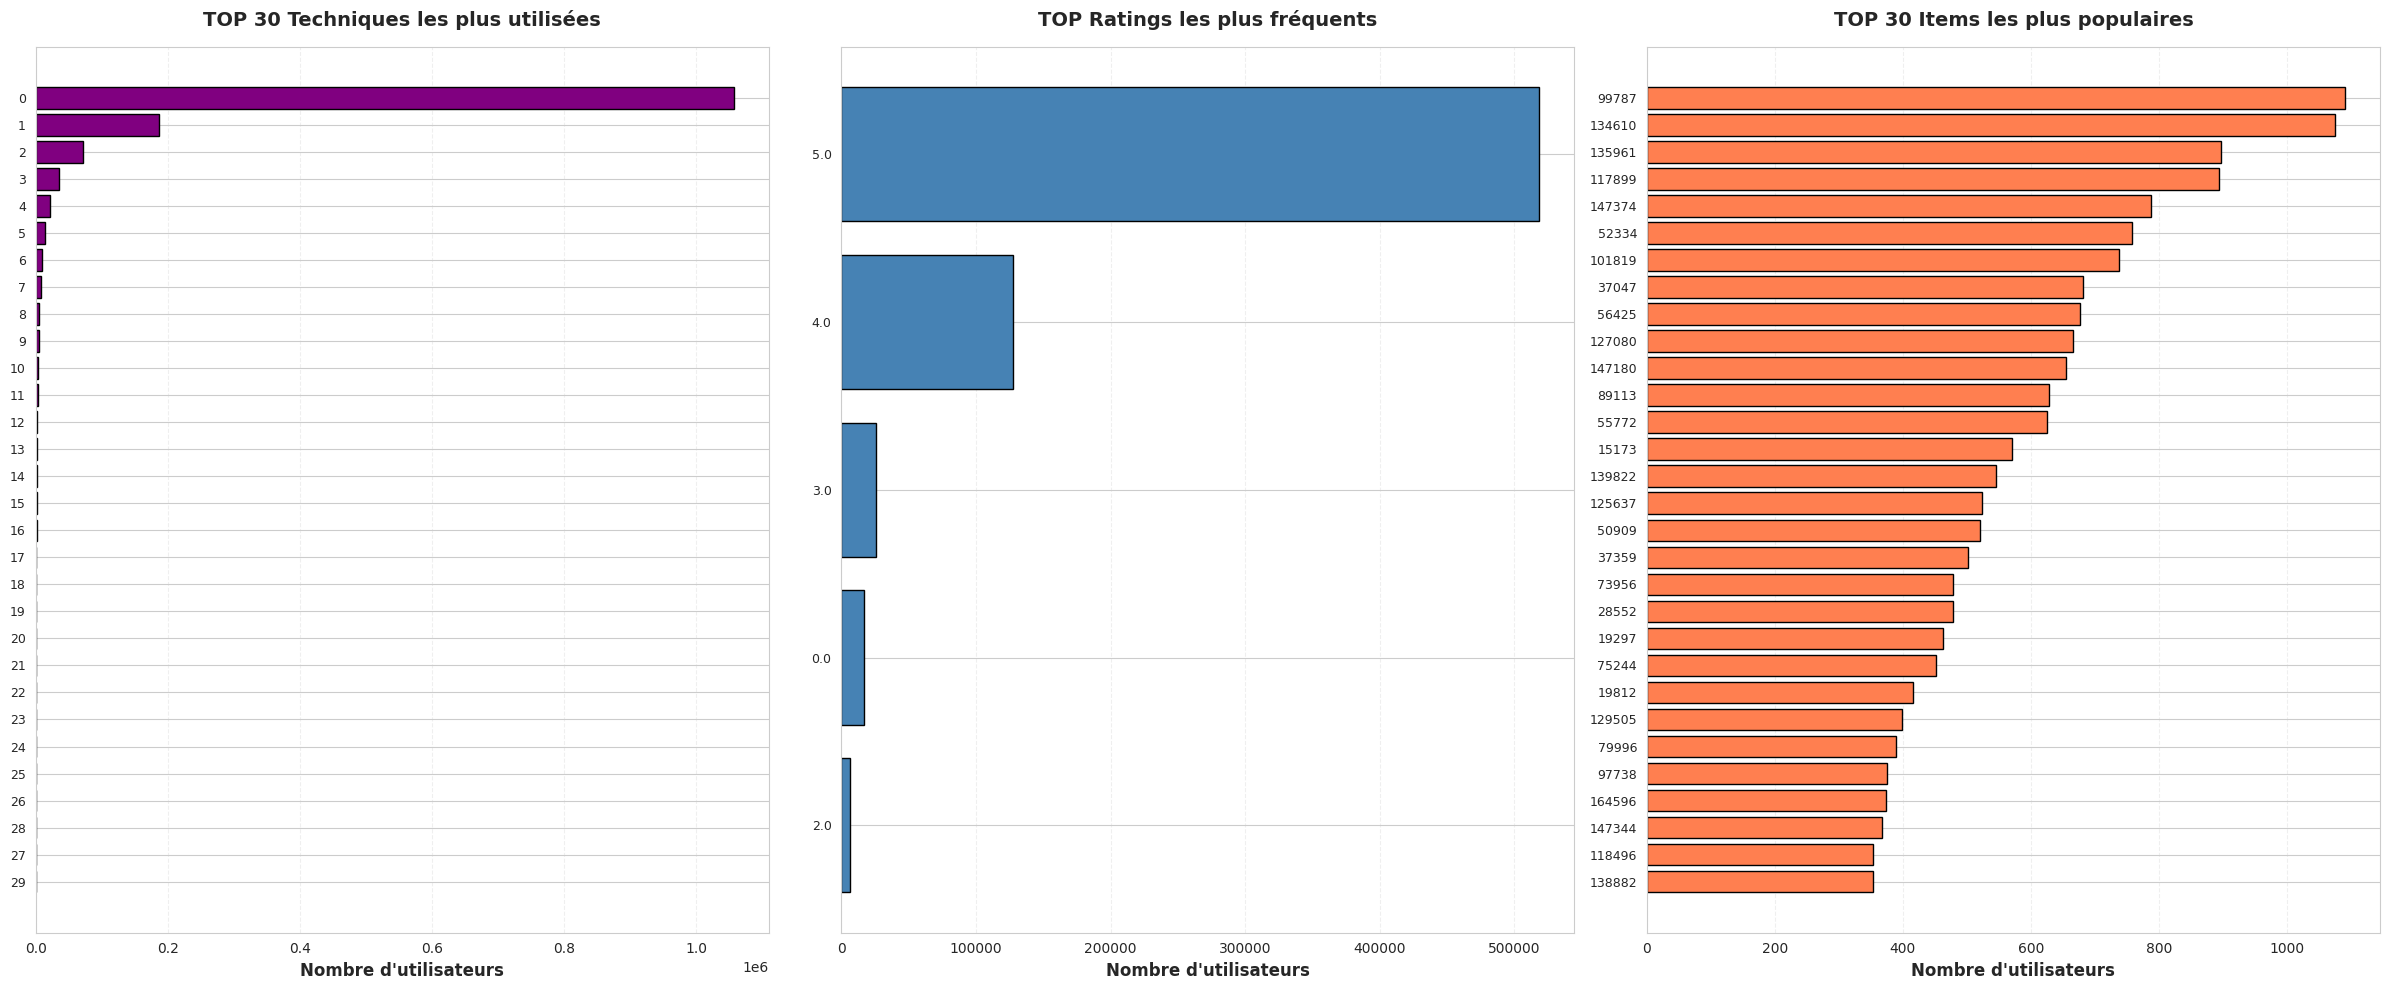

In [20]:
# Analyse TECHNIQUES, RATINGS et ITEMS utilisateurs
print("=" * 80)
print("ANALYSE DÉTAILLÉE - TECHNIQUES, RATINGS et ITEMS")
print("=" * 80)

# 1. Analyse TECHNIQUES
all_techniques = []
for tech_list in users['techniques'].apply(parse_list_col):
    all_techniques.extend(tech_list)
technique_counts = Counter(all_techniques)

# 2. Analyse RATINGS
all_ratings = []
for rating_list in users['ratings'].apply(parse_list_col):
    all_ratings.extend(rating_list)
rating_counts = Counter(all_ratings)

# 3. Analyse ITEMS
all_items = []
for item_list in users['items'].apply(parse_list_col):
    all_items.extend(item_list)
item_counts = Counter(all_items)

# Statistiques
print(f"\n📊 STATISTIQUES GLOBALES:")
print(f"\n   TECHNIQUES:")
print(f"      • Total techniques uniques: {len(technique_counts):,}")
print(f"      • Total techniques (avec répétitions): {len(all_techniques):,}")

print(f"\n   RATINGS:")
print(f"      • Total ratings uniques: {len(rating_counts):,}")
print(f"      • Total ratings (avec répétitions): {len(all_ratings):,}")

print(f"\n   ITEMS:")
print(f"      • Total items uniques: {len(item_counts):,}")
print(f"      • Total items (avec répétitions): {len(all_items):,}")

# TOP 30 pour chaque catégorie
print(f"\n🏆 TOP 30 TECHNIQUES:")
print(f"{'Technique':<40} {'Count':>10} {'% Users':>12}")
print("-" * 65)
for tech, count in technique_counts.most_common(30):
    pct = 100 * count / len(users)
    print(f"{tech:<40} {count:>10,} {pct:>11.1f}%")

print(f"\n🏆 TOP RATINGS:")
print(f"{'Rating':<40} {'Count':>10} {'% Users':>12}")
print("-" * 65)
for rating, count in rating_counts.most_common(30):
    pct = 100 * count / len(users)
    print(f"{str(rating):<40} {count:>10,} {pct:>11.1f}%")

print(f"\n🏆 TOP 30 ITEMS:")
print(f"{'Item':<40} {'Count':>10} {'% Users':>12}")
print("-" * 65)
for item, count in item_counts.most_common(30):
    pct = 100 * count / len(users)
    print(f"{str(item):<40} {count:>10,} {pct:>11.1f}%")

# Visualisations - TOP 30 pour chaque catégorie (3 graphiques horizontaux)
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# 1. TOP 30 TECHNIQUES
top_30_techniques = technique_counts.most_common(30)
tech_names = [t[0] for t in top_30_techniques]
tech_counts_vals = [t[1] for t in top_30_techniques]

axes[0].barh(range(len(tech_names)), tech_counts_vals, color='purple', edgecolor='black')
axes[0].set_yticks(range(len(tech_names)))
axes[0].set_yticklabels(tech_names, fontsize=9)
axes[0].set_xlabel('Nombre d\'utilisateurs', fontsize=12, fontweight='bold')
axes[0].set_title('TOP 30 Techniques les plus utilisées', fontsize=14, fontweight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# 2. TOP RATINGS
top_ratings = rating_counts.most_common(5)
rating_names = [str(t[0]) for t in top_ratings]
rating_counts_vals = [t[1] for t in top_ratings]

axes[1].barh(range(len(rating_names)), rating_counts_vals, color='steelblue', edgecolor='black')
axes[1].set_yticks(range(len(rating_names)))
axes[1].set_yticklabels(rating_names, fontsize=9)
axes[1].set_xlabel('Nombre d\'utilisateurs', fontsize=12, fontweight='bold')
axes[1].set_title('TOP Ratings les plus fréquents', fontsize=14, fontweight='bold', pad=15)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

# 3. TOP 30 ITEMS
top_30_items = item_counts.most_common(30)
item_names = [str(t[0]) for t in top_30_items]
item_counts_vals = [t[1] for t in top_30_items]

axes[2].barh(range(len(item_names)), item_counts_vals, color='coral', edgecolor='black')
axes[2].set_yticks(range(len(item_names)))
axes[2].set_yticklabels(item_names, fontsize=9)
axes[2].set_xlabel('Nombre d\'utilisateurs', fontsize=12, fontweight='bold')
axes[2].set_title('TOP 30 Items les plus populaires', fontsize=14, fontweight='bold', pad=15)
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 8. 🔗 Relations entre Fichiers

In [21]:
print("=" * 80)
print("ANALYSE DES RELATIONS ENTRE FICHIERS")
print("=" * 80)

# Join interactions + recipes (avec toutes les colonnes nécessaires)
recipes_cols_to_merge = ['id', 'name', 'minutes', 'n_steps', 'n_ingredients']
interactions_recipes = interactions_train.merge(
    recipes[recipes_cols_to_merge],
    left_on='recipe_id',
    right_on='id',
    how='left'
)

print(f"\n INTERACTIONS + RECIPES:")
print(f"   • Nombre d'interactions avec recette: {interactions_recipes['id'].notna().sum():,}")
print(f"   • Nombre d'interactions sans recette: {interactions_recipes['id'].isna().sum():,}")


# Recettes les plus populaires avec leurs caractéristiques
print(f"\n🏆 TOP 10 Recettes les plus interagies:")
top_recipes_stats = interactions_recipes.groupby('recipe_id').agg({
    'user_id': 'count',
    'rating': 'mean',
    'name': 'first',
    'minutes': 'first',
}).sort_values('user_id', ascending=False).head(10)
top_recipes_stats.columns = ['n_interactions', 'avg_rating', 'name', 'minutes']
print(top_recipes_stats)

ANALYSE DES RELATIONS ENTRE FICHIERS

 INTERACTIONS + RECIPES:
   • Nombre d'interactions avec recette: 698,901
   • Nombre d'interactions sans recette: 0

🏆 TOP 10 Recettes les plus interagies:
           n_interactions  avg_rating  \
recipe_id                               
27208                1091    4.413382   
89204                1075    4.346977   
32204                 897    4.608696   
39087                 894    4.691275   
69173                 787    4.777637   
54257                 758    4.420844   
22782                 738    4.589431   
68955                 681    4.440529   
25885                 677    4.491876   
28148                 666    4.714715   

                                                        name  minutes  
recipe_id                                                              
27208                             to die for crock pot roast      545  
89204      crock pot chicken with black beans   cream cheese      243  
32204                   

### 8.2 Analyse temporelle - Dates soumission

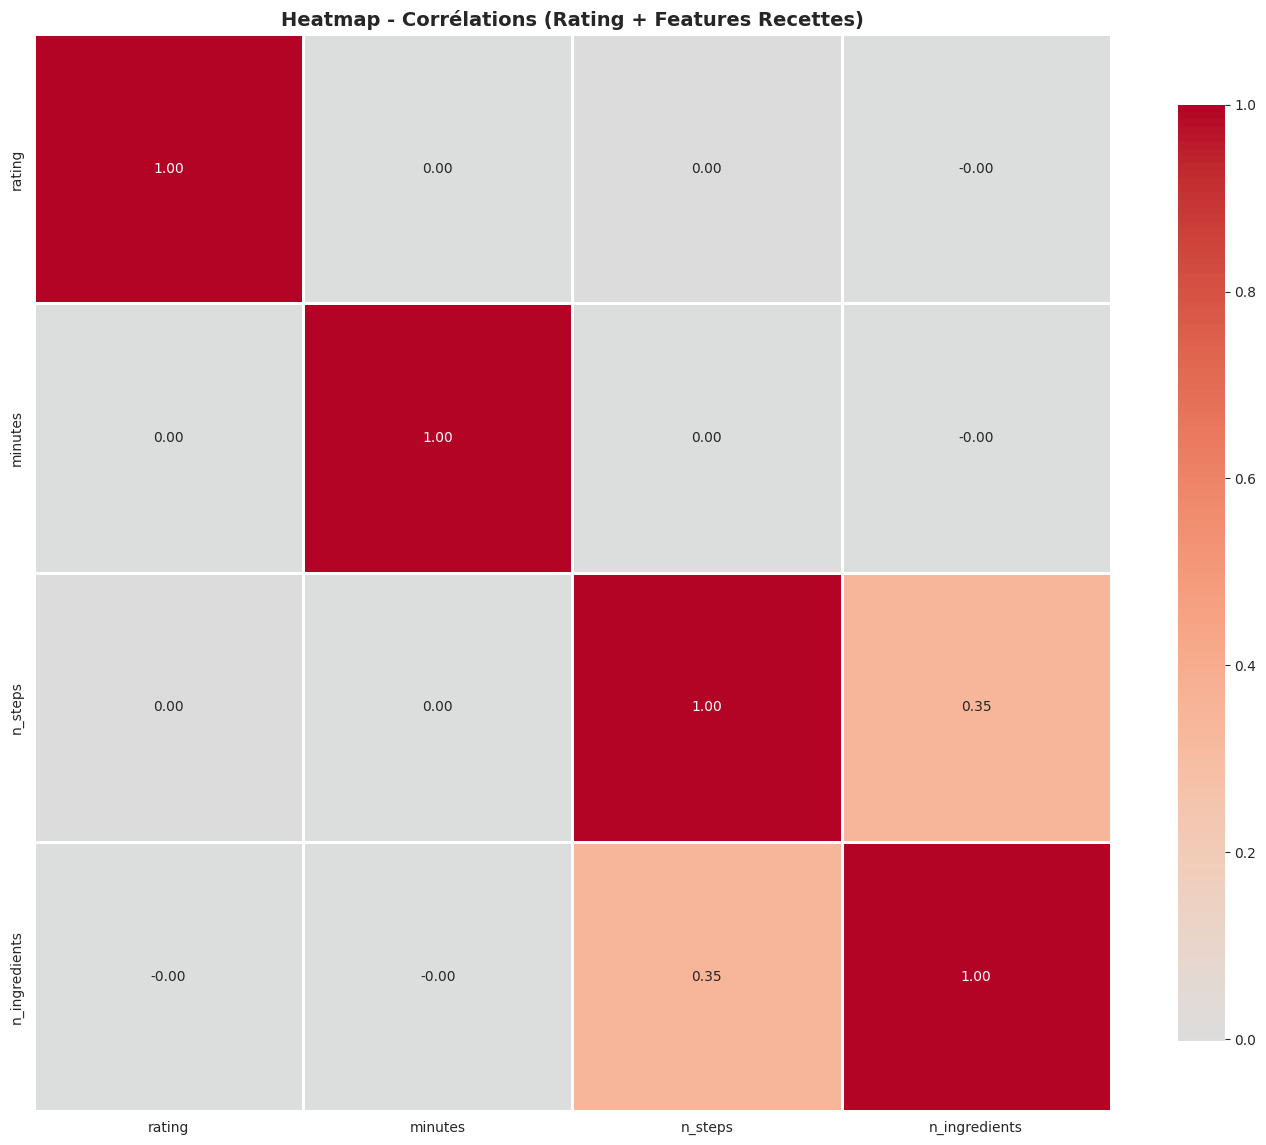


 CORRÉLATIONS AVEC RATING:
rating           1.000000
n_steps          0.003222
minutes          0.000677
n_ingredients   -0.001719
Name: rating, dtype: float64


In [22]:
# Heatmap corrélations Rating vs toutes les features numériques
correlation_cols = ['rating', 'minutes', 'n_steps', 'n_ingredients']
corr_matrix = interactions_recipes[correlation_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Heatmap - Corrélations (Rating + Features Recettes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\n CORRÉLATIONS AVEC RATING:")
rating_corr = corr_matrix['rating'].sort_values(ascending=False)
print(rating_corr)

## 10. 📋 Synthèse Finale - Insights Principaux

In [ ]:
print("=" * 80)
print("SYNTHÈSE FINALE - INSIGHTS PRINCIPAUX DE L'EDA")
print("=" * 80)

print(f"\n DONNÉES DISPONIBLES:")
print(f"   • Interactions (train):  {len(interactions_train):>10,}")
print(f"   • Recettes:              {len(recipes):>10,}")
print(f"   • Utilisateurs:          {len(users):>10,}")

print(f"\nINTERACTIONS:")
print(f"   • Rating moyen:          {interactions_train['rating'].mean():>10.2f}")
print(f"   • Rating médian:         {interactions_train['rating'].median():>10.0f}")
print(f"   • % ratings = 5:         {100 * (interactions_train['rating'] == 5).sum() / len(interactions_train):>10.1f}%")
print(f"   • Users uniques:         {interactions_train['user_id'].nunique():>10,}")
print(f"   • Recettes uniques:      {interactions_train['recipe_id'].nunique():>10,}")

print(f"\n🍳 RECETTES:")
print(f"   • Minutes (médiane):     {recipes['minutes'].median():>10.0f}")
print(f"   • Steps (médiane):       {recipes['n_steps'].median():>10.0f}")
print(f"   • Ingredients (médiane): {recipes['n_ingredients'].median():>10.0f}")
print(f"   • Calories (médiane):    {recipes['calories'].median():>10.0f}")
print(f"   • Tags uniques:          {len(tag_counts):>10,}")
print(f"   • Ingredients uniques:   {len(ingredient_counts):>10,}")

print(f"\n UTILISATEURS:")
print(f"   • Techniques uniques:    {len(technique_counts):>10,}")
print(f"   • Items uniques:         {len(item_counts):>10,}")
print(f"   • Ratings uniques:       {len(rating_counts):>10,}")

print(f"\nQUALITÉ DES DONNÉES:")
missing_summary = pd.DataFrame({
    'Dataset': ['Interactions', 'Recipes', 'Users'],
    'Total_Rows': [len(interactions_train), len(recipes), len(users)],
    'Missing_Values': [
        interactions_train.isnull().sum().sum(),
        recipes.isnull().sum().sum(),
        users.isnull().sum().sum()
    ]
})
print(missing_summary.to_string(index=False))

print(f"\n✅ PROCHAINES ÉTAPES RECOMMANDÉES:")
print(f"   1. Nettoyage des outliers dans nutrition et minutes")
print(f"   2. Traitement des valeurs manquantes")
print(f"   3. Feature engineering (tags, ingredients, nutrition)")
print(f"   4. Création de features temporelles")
print(f"   5. Encodage des variables catégorielles")

print(f"\n" + "=" * 80)
print("FIN DE L'EXPLORATION DES DONNÉES")
print("=" * 80)

SYNTHÈSE FINALE - INSIGHTS PRINCIPAUX DE L'EDA

📊 DONNÉES DISPONIBLES:
   • Interactions (train):     698,901
   • Recettes:                 231,637
   • Utilisateurs:              25,076

⭐ INTERACTIONS:
   • Rating moyen:                4.57
   • Rating médian:                  5
   • % ratings = 5:               74.2%
   • Users uniques:             25,076
   • Recettes uniques:         160,901

🍳 RECETTES:
   • Minutes (médiane):             40
   • Steps (médiane):                9
   • Ingredients (médiane):          9
   • Calories (médiane):           313
   • Tags uniques:                 552
   • Ingredients uniques:       14,942

👥 UTILISATEURS:
   • Techniques uniques:           559
   • Items uniques:            160,901
   • Ratings uniques:                6

⚠️  QUALITÉ DES DONNÉES:
     Dataset  Total_Rows  Missing_Values
Interactions      698901               0
     Recipes      231637            4980
       Users       25076               0

✅ PROCHAINES ÉTAPES RECOMMA